        MIS 522 - MANAGEMENT INFORMATION SYSTEM PRACTICUM
        POKHARA UNIVERSITY - FACULTY OF MANAGEMENT STUDIES

        UNIT I : DATA COLLECTION, CLEANING AND PREPARATION
        (3 Hours)

        COMPLETE GOOGLE COLAB WORKBOOK


In [ ]:
'''



===============================================================================
 PART 0 : BUSINESS SCENARIO
===============================================================================

 COMPANY
 -------
 Sagarmatha Retail Pvt. Ltd. is an omni-channel retailer based in
 Kathmandu, operating across all seven provinces of Nepal through
 physical stores, a website and a mobile application.

        Omnichannel is a business strategy providing a seamless,
                connected customer experience across multiple touchpoints,
                including online websites, mobile apps, social media,
                and physical stores




 THE PROBLEM
 -----------
 The company recently migrated from three separate systems into a
 single ERP:

        - the in-store POS system
        - the e-commerce platform database
        - a manually maintained customer register in Excel

 The migration was rushed. The MIS department has exported two raw
 tables and they are full of defects: the same order appears twice,
 province names are typed in different cases, some prices were entered
 with the paisa places shifted, and a number of fields are simply blank.




 YOUR ROLE
 ---------                 TARKARI KINNE > SAFA GARNE > CUT GARNE > COOK GARNE > TASTE GARNE > SERVE

You are the MIS Analyst. Management cannot make any decision until
 somebody produces a trustworthy dataset. Your job in Unit I is to
 audit, clean, enrich and summarise this data, then hand over a
 cleaned file plus a report of what you found.


'''

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error


In [3]:

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

rng = np.random.default_rng(42)      # fixed seed = reproducible results

print("All libraries loaded successfully.")


All libraries loaded successfully.


In [4]:

# ---------- TABLE 2 : CUSTOMER MASTER ----------
NC = 900
cities = {"Bagmati":["Kathmandu","Lalitpur","Bhaktapur","Hetauda"],
          "Gandaki":["Pokhara","Damauli","Gorkha"],
          "Lumbini":["Butwal","Nepalgunj","Dang"],
          "Koshi":["Biratnagar","Dharan","Itahari"],
          "Madhesh":["Janakpur","Birgunj"],
          "Sudurpashchim":["Dhangadhi","Mahendranagar"],
          "Karnali":["Surkhet","Birendranagar"]}
provs = list(cities)
pw    = [.33, .16, .16, .15, .11, .06, .03]

cust = []
for i in range(1, NC + 1):
    p = rng.choice(provs, p=pw)
    cust.append({
        "customer_id"    : f"CUST{i:04d}",
        "gender"         : rng.choice(["Male","Female"], p=[.54,.46]),
        "age"            : int(np.clip(rng.normal(36, 11), 18, 72)),
        "city"           : rng.choice(cities[p]),
        "province"       : p,
        "segment"        : rng.choice(["Retail","Corporate","Wholesale"],
                                      p=[.66,.20,.14]),
        "join_date"      : (pd.Timestamp("2021-01-01") +
                            pd.Timedelta(days=int(rng.integers(0,1400)))
                            ).strftime("%Y-%m-%d"),
        "loyalty_member" : rng.choice(["Yes","No"], p=[.42,.58])})


cust_raw = pd.DataFrame(cust)


In [5]:
cust_raw

,customer_id,gender,age,city,province,segment,join_date,loyalty_member
0,CUST0001,Male,44,Biratnagar,Koshi,Retail,2023-09-04,No
1,CUST0002,Female,35,Itahari,Koshi,Retail,2022-09-23,No
2,CUST0003,Female,41,Nepalgunj,Lumbini,Retail,2021-11-15,Yes
3,CUST0004,Female,33,Birgunj,Madhesh,Wholesale,2022-05-12,No
4,CUST0005,Male,41,Dharan,Koshi,Retail,2021-03-03,No
...,...,...,...,...,...,...,...,...
895,CUST0896,Male,45,Pokhara,Gandaki,Corporate,2022-04-01,Yes
896,CUST0897,Male,37,Itahari,Koshi,Retail,2021-07-25,No
897,CUST0898,Male,25,Damauli,Gandaki,Retail,2024-02-20,No
898,CUST0899,Male,46,Pokhara,Gandaki,Retail,2022-10-18,No


In [6]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=cust_raw)

https://docs.google.com/spreadsheets/d/1FQMjHA_mHI-WuiNhrP0jmx_3xMKBDX3JE1D3Q7NMaYI/edit#gid=0


In [7]:



# ---------- INJECT REALISTIC DEFECTS ---------- DATA LAI BIGRNE



# ---------- TABLE 1 : SALES TRANSACTIONS ----------
cats = {"Electronics":["Smartphone","Laptop","Earbuds","Power Bank"],
        "Groceries"  :["Rice 25kg","Cooking Oil","Tea Pack","Lentils"],
        "Apparel"    :["Jacket","Sneakers","T-Shirt","Daura Suruwal"],
        "Home"       :["Gas Stove","Blanket","Water Filter"],
        "Beauty"     :["Face Cream","Shampoo","Perfume"]}

price = {"Smartphone":45000, "Laptop":95000, "Earbuds":3500, "Power Bank":2200,
         "Rice 25kg":2800, "Cooking Oil":420, "Tea Pack":350, "Lentils":220,
         "Jacket":4500, "Sneakers":3800, "T-Shirt":900, "Daura Suruwal":6500,
         "Gas Stove":7200, "Blanket":2600, "Water Filter":11000,
         "Face Cream":1200, "Shampoo":650, "Perfume":2900}

loy = dict(zip(cust_raw.customer_id, cust_raw.loyalty_member))

# Festival seasonality (Sep-Nov) + Nepali New Year (Apr) + growth trend
dates = pd.date_range("2024-01-01", "2025-12-31", freq="D")
w = np.array([1 + .6*(d.month in (9,10,11)) + .3*(d.month == 4)
              + .0009*(d - dates[0]).days for d in dates])
w = w / w.sum()

N  = 6000
od = rng.choice(dates, size=N, p=w)
rows = []
for i in range(N):
    cid  = f"CUST{rng.integers(1, NC+1):04d}"
    c    = rng.choice(list(cats), p=[.20,.34,.21,.13,.12])
    prod = rng.choice(cats[c])
    up   = price[prod]
    disc = float(rng.choice([0,0,0,5,10,15,20], p=[.38,.15,.10,.13,.10,.09,.05]))
    d    = pd.Timestamp(od[i])
    fest = int(d.month in (9,10,11))

    # ---- TRUE DEMAND MODEL (recovered later by regression) ----
    q = (16.5
         - 1.35 * np.log(up)
         + 0.055 * disc
         + 0.60  * fest
         + 0.45  * (loy[cid] == "Yes")
         + rng.normal(0, 0.85))
    q = int(np.clip(round(q), 1, 12))

    rows.append({
        "order_id"      : f"ORD{100000+i}",
        "order_date"    : d.strftime("%Y-%m-%d"),
        "customer_id"   : cid,
        "category"      : c,
        "product"       : prod,
        "quantity"      : q,
        "unit_price"    : up,
        "discount_pct"  : disc,
        "channel"       : rng.choice(["In-Store","Website","Mobile App"],
                                     p=[.45,.30,.25]),
        "payment_method": rng.choice(["eSewa","Khalti","Cash on Delivery",
                                      "Card","Bank Transfer"],
                                     p=[.27,.19,.32,.14,.08]),
        "delivery_days" : int(rng.integers(1, 9))})
sales_raw = pd.DataFrame(rows)





In [8]:
sales_raw

,order_id,order_date,customer_id,category,product,quantity,unit_price,discount_pct,channel,payment_method,delivery_days
0,ORD100000,2025-11-20,CUST0726,Apparel,Jacket,6,4500,10.0,In-Store,Card,5
1,ORD100001,2025-05-31,CUST0119,Electronics,Laptop,2,95000,10.0,Website,Khalti,6
2,ORD100002,2025-11-29,CUST0388,Home,Gas Stove,7,7200,10.0,In-Store,eSewa,6
3,ORD100003,2025-09-23,CUST0046,Groceries,Cooking Oil,10,420,10.0,Website,Cash on Delivery,1
4,ORD100004,2025-11-18,CUST0308,Beauty,Perfume,6,2900,0.0,Website,eSewa,7
...,...,...,...,...,...,...,...,...,...,...,...
5995,ORD105995,2025-11-25,CUST0319,Electronics,Earbuds,7,3500,0.0,In-Store,eSewa,7
5996,ORD105996,2025-07-26,CUST0370,Groceries,Lentils,9,220,0.0,Mobile App,eSewa,2
5997,ORD105997,2024-04-16,CUST0370,Beauty,Face Cream,6,1200,10.0,Website,Cash on Delivery,6
5998,ORD105998,2025-06-04,CUST0367,Apparel,Jacket,6,4500,15.0,Website,Khalti,4


In [9]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=sales_raw)

https://docs.google.com/spreadsheets/d/1I5FW3zQnv7fgaGagxkBK5OOHEc1nrRkgNoSgvcDr4-E/edit#gid=0


In [10]:

# ---------- INJECT REALISTIC DEFECTS ---------- DATA LAI BIGRNE


# 1. duplicate rows (double-posted orders)
sales_raw = pd.concat([sales_raw, sales_raw.sample(180, random_state=1)],
                      ignore_index=True)

# 2. missing values
for col, k in [("quantity",260), ("unit_price",190),
               ("delivery_days",150), ("payment_method",120)]:
    sales_raw.loc[rng.choice(len(sales_raw), k, replace=False), col] = np.nan

# 3. inconsistent text case and stray whitespace
ix = rng.choice(len(sales_raw), 420, replace=False)
sales_raw.loc[ix,"category"] = sales_raw.loc[ix,"category"].str.upper()
ix = rng.choice(len(sales_raw), 200, replace=False)
sales_raw.loc[ix,"category"] = "  " + sales_raw.loc[ix,"category"].str.lower() + "  "

# 4. impossible values
sales_raw.loc[rng.choice(len(sales_raw), 55, replace=False), "quantity"]  = -2
sales_raw.loc[rng.choice(len(sales_raw), 22, replace=False), "unit_price"] *= 100

# 5. mixed date formats (dd/mm/yyyy vs yyyy-mm-dd)
ix = rng.choice(len(sales_raw), 300, replace=False)
sales_raw.loc[ix,"order_date"] = pd.to_datetime(
    sales_raw.loc[ix,"order_date"]).dt.strftime("%d/%m/%Y")

sales_raw = sales_raw.sample(frac=1, random_state=7).reset_index(drop=True)

# defects in the customer master
cust_raw = pd.concat([cust_raw, cust_raw.sample(35, random_state=3)],
                     ignore_index=True)
for col, k in [("age",70), ("segment",55), ("gender",45)]:
    cust_raw.loc[rng.choice(len(cust_raw), k, replace=False), col] = np.nan
ix = rng.choice(len(cust_raw), 150, replace=False)
cust_raw.loc[ix,"gender"] = cust_raw.loc[ix,"gender"].astype(str).str[0].str.upper()
cust_raw.loc[rng.choice(len(cust_raw), 18, replace=False), "age"] = 999
cust_raw.loc[rng.choice(len(cust_raw),  9, replace=False), "age"] = -5
ix = rng.choice(len(cust_raw), 120, replace=False)
cust_raw.loc[ix,"province"] = cust_raw.loc[ix,"province"].str.upper()

print("RAW SALES     :", sales_raw.shape)
print("RAW CUSTOMERS :", cust_raw.shape)


sales_raw.head(10)


RAW SALES     : (6180, 11)
RAW CUSTOMERS : (935, 8)


,order_id,order_date,customer_id,category,product,quantity,unit_price,discount_pct,channel,payment_method,delivery_days
0,ORD102535,24/11/2025,CUST0096,Groceries,Tea Pack,10.0,350.0,15.0,In-Store,eSewa,2.0
1,ORD100740,2025-10-31,CUST0032,Electronics,Smartphone,2.0,45000.0,0.0,Mobile App,Card,3.0
2,ORD101682,2025-05-28,CUST0544,apparel,T-Shirt,7.0,900.0,0.0,Mobile App,Cash on Delivery,1.0
3,ORD101409,2025-12-14,CUST0446,Groceries,Rice 25kg,5.0,2800.0,0.0,Website,eSewa,5.0
4,ORD105100,2025-11-02,CUST0513,Groceries,Cooking Oil,9.0,420.0,0.0,In-Store,Khalti,6.0
5,ORD102467,2025-11-09,CUST0410,Electronics,Laptop,1.0,95000.0,0.0,Mobile App,Cash on Delivery,4.0
6,ORD100445,2024-07-08,CUST0210,Apparel,Daura Suruwal,4.0,6500.0,0.0,In-Store,Khalti,1.0
7,ORD102520,2025-04-26,CUST0161,Apparel,Jacket,7.0,4500.0,0.0,In-Store,Khalti,7.0
8,ORD101195,2024-09-08,CUST0543,Groceries,Cooking Oil,7.0,420.0,0.0,Website,eSewa,5.0
9,ORD102820,2025-11-26,CUST0858,Home,Water Filter,3.0,NaN,0.0,Mobile App,eSewa,8.0


In [11]:
cust_raw

,customer_id,gender,age,city,province,segment,join_date,loyalty_member
0,CUST0001,Male,44.0,Biratnagar,Koshi,Retail,2023-09-04,No
1,CUST0002,Female,35.0,Itahari,Koshi,Retail,2022-09-23,No
2,CUST0003,Female,41.0,Nepalgunj,LUMBINI,Retail,2021-11-15,Yes
3,CUST0004,Female,33.0,Birgunj,Madhesh,Wholesale,2022-05-12,No
4,CUST0005,Male,41.0,Dharan,Koshi,Retail,2021-03-03,No
...,...,...,...,...,...,...,...,...
930,CUST0052,Male,31.0,Nepalgunj,Lumbini,Retail,2022-11-01,Yes
931,CUST0062,NaN,38.0,Damauli,Gandaki,Retail,2022-01-14,Yes
932,CUST0082,Female,38.0,Dharan,Koshi,Corporate,2022-03-19,No
933,CUST0634,Male,27.0,Pokhara,GANDAKI,Corporate,2023-08-19,No


In [12]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=cust_raw)

https://docs.google.com/spreadsheets/d/1N11lJPYxwgWE9J0rjcfLY6ileEbQPdjlmg6qEHdRnAE/edit#gid=0


In [13]:

#DATA QUALITY AUDIT
#Before touching anything, measure the damage. You cannot claim your
#cleaning worked unless you recorded the starting position.



def audit(data, name):
    print("=" * 62)
    print(f"AUDIT : {name}")
    print("=" * 62)
    print(f"Rows              : {data.shape[0]:,}")
    print(f"Columns           : {data.shape[1]}")
    print(f"Duplicate rows    : {data.duplicated().sum():,}")
    print(f"Total missing     : {int(data.isnull().sum().sum()):,}")
    print("\nMissing per column:")
    miss = data.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    for k, v in miss.items():
        print(f"   {k:<18} {v:>5}  ({v/len(data)*100:5.2f}%)")
    print()

audit(sales_raw, "sales_raw")
audit(cust_raw,  "customers_raw")

print("=" * 62)
print("TEXT INCONSISTENCY CHECK")
print("=" * 62)
print("category values found :", sorted(sales_raw.category.dropna().unique())[:8])
print("gender values found   :", sorted(cust_raw.gender.dropna().unique()))
print("province values found :", sorted(cust_raw.province.dropna().unique())[:8])

print("\n" + "=" * 62)
print("IMPOSSIBLE VALUE CHECK")
print("=" * 62)
print("Negative quantity rows :", (sales_raw.quantity < 0).sum())
print("Age above 90           :", (cust_raw.age > 90).sum())
print("Age below 15           :", (cust_raw.age < 15).sum())
print("Max unit_price found   :", sales_raw.unit_price.max())



AUDIT : sales_raw
Rows              : 6,180
Columns           : 11
Duplicate rows    : 98
Total missing     : 717

Missing per column:
   quantity             257  ( 4.16%)
   unit_price           190  ( 3.07%)
   delivery_days        150  ( 2.43%)
   payment_method       120  ( 1.94%)

AUDIT : customers_raw
Rows              : 935
Columns           : 8
Duplicate rows    : 15
Total missing     : 156

Missing per column:
   age                   65  ( 6.95%)
   segment               55  ( 5.88%)
   gender                36  ( 3.85%)

TEXT INCONSISTENCY CHECK
category values found : ['  apparel  ', '  beauty  ', '  electronics  ', '  groceries  ', '  home  ', 'APPAREL', np.str_('Apparel'), 'BEAUTY']
gender values found   : ['F', np.str_('Female'), 'M', np.str_('Male'), 'N']
province values found : ['BAGMATI', np.str_('Bagmati'), 'GANDAKI', np.str_('Gandaki'), 'KARNALI', 'KOSHI', np.str_('Karnali'), np.str_('Koshi')]

IMPOSSIBLE VALUE CHECK
Negative quantity rows : 55
Age above 90        

In [14]:







#CLEANING STEP 1 - REMOVE DUPLICATES
'''
  A duplicate in a transaction table means one sale counted twice, which
 inflates revenue. A duplicate in a master table means one customer
 counted twice, which deflates average spend per customer.
'''


log = []
s = sales_raw.copy()
c = cust_raw.copy()




before = len(s)
s = s.drop_duplicates()
log.append(f"Sales      : removed {before-len(s)} fully duplicate rows")




before = len(c)
c = c.drop_duplicates(subset="customer_id", keep="first")
log.append(f"Customers  : removed {before-len(c)} duplicate customer IDs")



print("\n".join(log))

print(f"\nSales now     : {s.shape}")

print(f"Customers now : {c.shape}")

print(f"customer_id unique? {c.customer_id.is_unique}")






Sales      : removed 98 fully duplicate rows
Customers  : removed 35 duplicate customer IDs

Sales now     : (6082, 11)
Customers now : (900, 8)
customer_id unique? True


In [15]:





# CLEANING STEP 2 - STANDARDISE TEXT AND DATES
'''
 "ELECTRONICS", "  electronics  " and "Electronics" are three different
  strings to a computer but one category to a human. Until they are
 unified, every group-by and every pivot table will be wrong.
'''



print("BEFORE :", sorted(s.category.dropna().unique()))

s["category"] = s["category"].str.strip().str.title()
c["province"] = c["province"].str.strip().str.title()

# gender arrives as Male / M / F / Female - map all of them to two values
c["gender"] = (c["gender"].astype(str).str.strip().str[0].str.upper()
                          .map({"M":"Male", "F":"Female"}))

s["order_date"] = pd.to_datetime(s["order_date"], format="mixed",
                                 dayfirst=True, errors="coerce")
c["join_date"]  = pd.to_datetime(c["join_date"], errors="coerce")



print("AFTER  :", sorted(s.category.unique()))

print("Gender :", c.gender.dropna().unique().tolist())

print("Province:", sorted(c.province.unique()))

print(f"\nDate range : {s.order_date.min().date()}  to  {s.order_date.max().date()}")

print(f"Unparseable dates : {s.order_date.isna().sum()}")




BEFORE : ['  apparel  ', '  beauty  ', '  electronics  ', '  groceries  ', '  home  ', 'APPAREL', np.str_('Apparel'), 'BEAUTY', np.str_('Beauty'), 'ELECTRONICS', np.str_('Electronics'), 'GROCERIES', np.str_('Groceries'), 'HOME', np.str_('Home')]
AFTER  : ['Apparel', 'Beauty', 'Electronics', 'Groceries', 'Home']
Gender : ['Male', 'Female']
Province: ['Bagmati', 'Gandaki', 'Karnali', 'Koshi', 'Lumbini', 'Madhesh', 'Sudurpashchim']

Date range : 2024-01-01  to  2025-12-31
Unparseable dates : 0


In [16]:






# CLEANING STEP 3 - HANDLE INVALID VALUES
'''

 Missing and invalid are not the same thing.

    MISSING   the value was never recorded         -> impute it
    INVALID   a value exists but cannot be true    -> delete or NaN it

'''



before = len(s)
s = s[s["quantity"].isna() | (s["quantity"] > 0)]
log.append(f"Dropped {before-len(s)} rows with negative quantity")


bad_age = ((c.age < 15) | (c.age > 90)).sum()
c.loc[(c.age < 15) | (c.age > 90), "age"] = np.nan
log.append(f"Converted {bad_age} impossible ages to NaN")



print(f"Rows with negative quantity dropped : {before-len(s)}")

print(f"Impossible ages converted to NaN    : {bad_age}")

print(f"Sales rows remaining                : {len(s):,}")





Rows with negative quantity dropped : 55
Impossible ages converted to NaN    : 26
Sales rows remaining                : 6,027


In [17]:




# CLEANING STEP 4 - HANDLE MISSING VALUES



s["quantity"]       = s["quantity"].fillna(s["quantity"].median())
s["unit_price"]     = s.groupby("product")["unit_price"].transform(
                          lambda x: x.fillna(x.median()))
s["delivery_days"]  = s["delivery_days"].fillna(s["delivery_days"].median())
s["payment_method"] = s["payment_method"].fillna(s["payment_method"].mode()[0])

c["age"]     = c["age"].fillna(c["age"].median())
c["segment"] = c["segment"].fillna("Unknown")
c["gender"]  = c["gender"].fillna("Unknown")

s["quantity"]      = s["quantity"].astype(int)
s["delivery_days"] = s["delivery_days"].astype(int)
c["age"]           = c["age"].astype(int)



print("Remaining missing in sales     :", int(s.isnull().sum().sum()))

print("Remaining missing in customers :", int(c.isnull().sum().sum()))

print("\nSegment distribution after imputation:")

print(c.segment.value_counts())





Remaining missing in sales     : 0
Remaining missing in customers : 0

Segment distribution after imputation:
segment
Retail       554
Corporate    173
Wholesale    118
Unknown       55
Name: count, dtype: int64


In [18]:




#   CLEANING STEP 5 - OUTLIER TREATMENT

# --- Show why IQR is the wrong tool here ---
q1, q3 = s.unit_price.quantile([.25, .75])
iqr_limit = q3 + 1.5 * (q3 - q1)
print(f"IQR upper limit          : NPR {iqr_limit:,.0f}")
print(f"Valid rows IQR would kill: {(s.unit_price > iqr_limit).sum():,}")



# --- The rule we actually apply ---
med  = s.groupby("product")["unit_price"].transform("median")
mask = s["unit_price"] > 10 * med
print(f"\nPer-product rule removes : {int(mask.sum())} rows")
print("Prices being removed     :", sorted(s.loc[mask,"unit_price"].unique())[:5])



s = s[~mask]
log.append(f"Removed {int(mask.sum())} price-entry errors (per-product rule)")
print(f"\nSales rows remaining     : {len(s):,}")
print(f"Max unit_price now       : NPR {s.unit_price.max():,.0f}")





IQR upper limit          : NPR 10,620
Valid rows IQR would kill: 859

Per-product rule removes : 22 rows
Prices being removed     : [np.float64(22000.0), np.float64(35000.0), np.float64(42000.0), np.float64(65000.0), np.float64(220000.0)]

Sales rows remaining     : 6,005
Max unit_price now       : NPR 95,000


In [19]:
sales_raw

,order_id,order_date,customer_id,category,product,quantity,unit_price,discount_pct,channel,payment_method,delivery_days
0,ORD102535,24/11/2025,CUST0096,Groceries,Tea Pack,10.0,350.0,15.0,In-Store,eSewa,2.0
1,ORD100740,2025-10-31,CUST0032,Electronics,Smartphone,2.0,45000.0,0.0,Mobile App,Card,3.0
2,ORD101682,2025-05-28,CUST0544,apparel,T-Shirt,7.0,900.0,0.0,Mobile App,Cash on Delivery,1.0
3,ORD101409,2025-12-14,CUST0446,Groceries,Rice 25kg,5.0,2800.0,0.0,Website,eSewa,5.0
4,ORD105100,2025-11-02,CUST0513,Groceries,Cooking Oil,9.0,420.0,0.0,In-Store,Khalti,6.0
...,...,...,...,...,...,...,...,...,...,...,...
6175,ORD105699,2024-03-22,CUST0570,beauty,Face Cream,NaN,1200.0,5.0,In-Store,Cash on Delivery,2.0
6176,ORD102550,04/09/2025,CUST0009,Apparel,Jacket,6.0,4500.0,5.0,Website,Cash on Delivery,1.0
6177,ORD100537,2024-05-31,CUST0180,Home,Blanket,6.0,2600.0,15.0,Website,eSewa,1.0
6178,ORD101220,18/05/2025,CUST0665,Groceries,Tea Pack,9.0,350.0,0.0,In-Store,eSewa,4.0


In [20]:
cust_raw

,customer_id,gender,age,city,province,segment,join_date,loyalty_member
0,CUST0001,Male,44.0,Biratnagar,Koshi,Retail,2023-09-04,No
1,CUST0002,Female,35.0,Itahari,Koshi,Retail,2022-09-23,No
2,CUST0003,Female,41.0,Nepalgunj,LUMBINI,Retail,2021-11-15,Yes
3,CUST0004,Female,33.0,Birgunj,Madhesh,Wholesale,2022-05-12,No
4,CUST0005,Male,41.0,Dharan,Koshi,Retail,2021-03-03,No
...,...,...,...,...,...,...,...,...
930,CUST0052,Male,31.0,Nepalgunj,Lumbini,Retail,2022-11-01,Yes
931,CUST0062,NaN,38.0,Damauli,Gandaki,Retail,2022-01-14,Yes
932,CUST0082,Female,38.0,Dharan,Koshi,Corporate,2022-03-19,No
933,CUST0634,Male,27.0,Pokhara,GANDAKI,Corporate,2023-08-19,No


In [27]:


# MERGE THE TWO TABLES

'''
 A LEFT JOIN keeps every sales row and attaches customer attributes
 where a match exists. Always check afterwards for orphan records -
 sales referencing a customer_id that does not exist in the master.
 That is a referential integrity failure and it is common after a
 system migration.

'''




df = s.merge(c, on="customer_id", how="left")

orphans = df.province.isna().sum()
print(f"Merged dataset shape : {df.shape}")
print(f"Orphan sales records : {orphans}")

if orphans:
    print("Action: these rows reference customers not in the master file.")
    df = df[df.province.notna()]

log.append(f"Merged sales + customers -> {df.shape[0]:,} rows")

print(f"\nColumns now available: {list(df.columns)}")




Merged dataset shape : (6005, 18)
Orphan sales records : 0

Columns now available: ['order_id', 'order_date', 'customer_id', 'category', 'product', 'quantity', 'unit_price', 'discount_pct', 'channel', 'payment_method', 'delivery_days', 'gender', 'age', 'city', 'province', 'segment', 'join_date', 'loyalty_member']


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6005 entries, 0 to 6004
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        6005 non-null   object        
 1   order_date      6005 non-null   datetime64[ns]
 2   customer_id     6005 non-null   object        
 3   category        6005 non-null   object        
 4   product         6005 non-null   object        
 5   quantity        6005 non-null   int64         
 6   unit_price      6005 non-null   float64       
 7   discount_pct    6005 non-null   float64       
 8   channel         6005 non-null   object        
 9   payment_method  6005 non-null   object        
 10  delivery_days   6005 non-null   int64         
 11  gender          6005 non-null   object        
 12  age             6005 non-null   int64         
 13  city            6005 non-null   object        
 14  province        6005 non-null   object        
 15  segm

In [29]:
print(df.isna().sum())

order_id          0
order_date        0
customer_id       0
category          0
product           0
quantity          0
unit_price        0
discount_pct      0
channel           0
payment_method    0
delivery_days     0
gender            0
age               0
city              0
province          0
segment           0
join_date         0
loyalty_member    0
dtype: int64


In [30]:
df

,order_id,order_date,customer_id,category,product,quantity,unit_price,discount_pct,channel,payment_method,delivery_days,gender,age,city,province,segment,join_date,loyalty_member
0,ORD102535,2025-11-24,CUST0096,Groceries,Tea Pack,10,350.0,15.0,In-Store,eSewa,2,Male,32,Janakpur,Madhesh,Corporate,2023-04-02,Yes
1,ORD100740,2025-10-31,CUST0032,Electronics,Smartphone,2,45000.0,0.0,Mobile App,Card,3,Male,35,Damauli,Gandaki,Wholesale,2022-01-03,Yes
2,ORD101682,2025-05-28,CUST0544,Apparel,T-Shirt,7,900.0,0.0,Mobile App,Cash on Delivery,1,Unknown,47,Nepalgunj,Lumbini,Corporate,2023-09-13,No
3,ORD101409,2025-12-14,CUST0446,Groceries,Rice 25kg,5,2800.0,0.0,Website,eSewa,5,Female,34,Hetauda,Bagmati,Retail,2023-11-01,No
4,ORD105100,2025-11-02,CUST0513,Groceries,Cooking Oil,9,420.0,0.0,In-Store,Khalti,6,Unknown,35,Bhaktapur,Bagmati,Wholesale,2023-02-05,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6000,ORD105699,2024-03-22,CUST0570,Beauty,Face Cream,7,1200.0,5.0,In-Store,Cash on Delivery,2,Female,32,Birgunj,Madhesh,Retail,2024-10-10,Yes
6001,ORD102550,2025-09-04,CUST0009,Apparel,Jacket,6,4500.0,5.0,Website,Cash on Delivery,1,Male,43,Itahari,Koshi,Corporate,2021-01-11,No
6002,ORD100537,2024-05-31,CUST0180,Home,Blanket,6,2600.0,15.0,Website,eSewa,1,Female,41,Lalitpur,Bagmati,Wholesale,2024-03-26,No
6003,ORD101220,2025-05-18,CUST0665,Groceries,Tea Pack,9,350.0,0.0,In-Store,eSewa,4,Female,62,Pokhara,Gandaki,Retail,2023-01-24,No


In [31]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1iNpF9YWN8MsnrWV28Kdar-4-GtBnwagkBoqLoaI07EM/edit#gid=0


In [32]:

#  FEATURE ENGINEERING

'''
 Feature engineering means creating NEW columns from existing ones so
 that the analysis can answer business questions the raw data cannot.
 The raw table has no revenue column at all - it has to be derived.
'''


'''
 EIGHTEEN FEATURES CREATED, IN FIVE FAMILIES
 ---------------------------------------------------

  1. MONETARY
        gross_amount      quantity x unit_price
        discount_amount   value given away in discounts
        revenue           the actual money received       <- KEY METRIC
        log_revenue       log transform, fixes right skew

  2. TIME
        year, month, month_num, quarter
        day_name          Monday ... Sunday
        is_weekend        1 if Saturday or Sunday
        is_festival       1 if Sep / Oct / Nov (Dashain, Tihar)

  3. CUSTOMER
        tenure_days       days between join_date and order_date
        age_group         18-25 / 26-35 / 36-45 / 46-60 / 60+
        cust_order_count  how many orders this customer placed
        is_repeat         1 if more than one order

  4. PRODUCT
        price_band        Budget / Mid / Premium / Luxury
        is_discounted     1 if any discount applied

  5. OPERATIONS
        delivery_speed    Fast (1-2d) / Normal (3-5d) / Slow (6d+)
'''



# ---- 1. MONETARY ----
df["gross_amount"]    = df.quantity * df.unit_price
df["discount_amount"] = (df.gross_amount * df.discount_pct / 100).round(2)
df["revenue"]         = (df.gross_amount - df.discount_amount).round(2)
df["log_revenue"]     = np.log1p(df.revenue)

# ---- 2. TIME ----
df["year"]        = df.order_date.dt.year
df["month"]       = df.order_date.dt.to_period("M").astype(str)
df["month_num"]   = df.order_date.dt.month
df["quarter"]     = "Q" + df.order_date.dt.quarter.astype(str)
df["day_name"]    = df.order_date.dt.day_name()
df["is_weekend"]  = df.order_date.dt.dayofweek.isin([5,6]).astype(int)
df["is_festival"] = df.month_num.isin([9,10,11]).astype(int)

# ---- 3. CUSTOMER ----
df["tenure_days"] = (df.order_date - df.join_date).dt.days

# VALIDATION - feature engineering exposes a hidden defect
bad_tenure = (df.tenure_days < 0).sum()
print(f"VALIDATION: orders dated BEFORE the customer's join_date : {bad_tenure}")
df.loc[df.tenure_days < 0, "tenure_days"] = 0

df["age_group"]        = pd.cut(df.age, [17,25,35,45,60,90],
                                labels=["18-25","26-35","36-45","46-60","60+"])
order_counts           = df.customer_id.value_counts()
df["cust_order_count"] = df.customer_id.map(order_counts)
df["is_repeat"]        = (df.cust_order_count > 1).astype(int)

# ---- 4. PRODUCT ----
df["price_band"]    = pd.cut(df.unit_price, [0,1000,5000,20000,1e6],
                             labels=["Budget","Mid","Premium","Luxury"])
df["is_discounted"] = (df.discount_pct > 0).astype(int)

# ---- 5. OPERATIONS ----
df["delivery_speed"] = pd.cut(df.delivery_days, [0,2,5,10],
                              labels=["Fast","Normal","Slow"])

print(f"\nColumns: 18 raw -> {df.shape[1]} after engineering")
print(f"Total revenue : NPR {df.revenue.sum()/1e6:,.1f} million")
print(f"Revenue skew  : raw {df.revenue.skew():.2f}  |  log {df.log_revenue.skew():.2f}")
df[["revenue","tenure_days","age_group","price_band","is_festival"]].head()









VALIDATION: orders dated BEFORE the customer's join_date : 223

Columns: 18 raw -> 36 after engineering
Total revenue : NPR 171.9 million
Revenue skew  : raw 5.46  |  log 0.23


,revenue,tenure_days,age_group,price_band,is_festival
0,2975.0,967,26-35,Budget,1
1,90000.0,1397,26-35,Luxury,1
2,6300.0,623,46-60,Budget,0
3,14000.0,774,26-35,Mid,0
4,3780.0,1001,26-35,Budget,1


In [33]:
df

,order_id,order_date,customer_id,category,product,quantity,unit_price,discount_pct,channel,payment_method,delivery_days,gender,age,city,province,segment,join_date,loyalty_member,gross_amount,discount_amount,revenue,log_revenue,year,month,month_num,quarter,day_name,is_weekend,is_festival,tenure_days,age_group,cust_order_count,is_repeat,price_band,is_discounted,delivery_speed
0,ORD102535,2025-11-24,CUST0096,Groceries,Tea Pack,10,350.0,15.0,In-Store,eSewa,2,Male,32,Janakpur,Madhesh,Corporate,2023-04-02,Yes,3500.0,525.0,2975.0,7.998335,2025,2025-11,11,Q4,Monday,0,1,967,26-35,8,1,Budget,1,Fast
1,ORD100740,2025-10-31,CUST0032,Electronics,Smartphone,2,45000.0,0.0,Mobile App,Card,3,Male,35,Damauli,Gandaki,Wholesale,2022-01-03,Yes,90000.0,0.0,90000.0,11.407576,2025,2025-10,10,Q4,Friday,0,1,1397,26-35,4,1,Luxury,0,Normal
2,ORD101682,2025-05-28,CUST0544,Apparel,T-Shirt,7,900.0,0.0,Mobile App,Cash on Delivery,1,Unknown,47,Nepalgunj,Lumbini,Corporate,2023-09-13,No,6300.0,0.0,6300.0,8.748464,2025,2025-05,5,Q2,Wednesday,0,0,623,46-60,10,1,Budget,0,Fast
3,ORD101409,2025-12-14,CUST0446,Groceries,Rice 25kg,5,2800.0,0.0,Website,eSewa,5,Female,34,Hetauda,Bagmati,Retail,2023-11-01,No,14000.0,0.0,14000.0,9.546884,2025,2025-12,12,Q4,Sunday,1,0,774,26-35,5,1,Mid,0,Normal
4,ORD105100,2025-11-02,CUST0513,Groceries,Cooking Oil,9,420.0,0.0,In-Store,Khalti,6,Unknown,35,Bhaktapur,Bagmati,Wholesale,2023-02-05,No,3780.0,0.0,3780.0,8.237744,2025,2025-11,11,Q4,Sunday,1,1,1001,26-35,8,1,Budget,0,Slow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6000,ORD105699,2024-03-22,CUST0570,Beauty,Face Cream,7,1200.0,5.0,In-Store,Cash on Delivery,2,Female,32,Birgunj,Madhesh,Retail,2024-10-10,Yes,8400.0,420.0,7980.0,8.984819,2024,2024-03,3,Q1,Friday,0,0,0,26-35,5,1,Mid,1,Fast
6001,ORD102550,2025-09-04,CUST0009,Apparel,Jacket,6,4500.0,5.0,Website,Cash on Delivery,1,Male,43,Itahari,Koshi,Corporate,2021-01-11,No,27000.0,1350.0,25650.0,10.152338,2025,2025-09,9,Q3,Thursday,0,1,1697,36-45,10,1,Mid,1,Fast
6002,ORD100537,2024-05-31,CUST0180,Home,Blanket,6,2600.0,15.0,Website,eSewa,1,Female,41,Lalitpur,Bagmati,Wholesale,2024-03-26,No,15600.0,2340.0,13260.0,9.492583,2024,2024-05,5,Q2,Friday,0,0,66,36-45,4,1,Mid,1,Fast
6003,ORD101220,2025-05-18,CUST0665,Groceries,Tea Pack,9,350.0,0.0,In-Store,eSewa,4,Female,62,Pokhara,Gandaki,Retail,2023-01-24,No,3150.0,0.0,3150.0,8.055475,2025,2025-05,5,Q2,Sunday,1,0,845,60+,9,1,Budget,0,Normal


In [35]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/184RuUcoAQ1EUz0Krvo1Uamsh3YvuHhj4MQtyvwhva2o/edit#gid=0


In [34]:
print(df.isna().sum())

order_id            0
order_date          0
customer_id         0
category            0
product             0
quantity            0
unit_price          0
discount_pct        0
channel             0
payment_method      0
delivery_days       0
gender              0
age                 0
city                0
province            0
segment             0
join_date           0
loyalty_member      0
gross_amount        0
discount_amount     0
revenue             0
log_revenue         0
year                0
month               0
month_num           0
quarter             0
day_name            0
is_weekend          0
is_festival         0
tenure_days         0
age_group           0
cust_order_count    0
is_repeat           0
price_band          0
is_discounted       0
delivery_speed      0
dtype: int64


In [36]:

#  PART 11 : NORMALISATION / NOT IMP RIGHT NOW


'''
 CONCEPT - WHY NORMALISE
 --------------------------
 unit_price ranges from 220 to 95,000. age ranges from 18 to 72. Any
 algorithm that measures distance (clustering, KNN) or compares
 coefficients would be dominated by unit_price purely because its
 numbers are bigger, not because it matters more.

'''




num_cols = ["quantity","unit_price","revenue","delivery_days","age","tenure_days"]

mm = pd.DataFrame(MinMaxScaler().fit_transform(df[num_cols]),
                  columns=[x+"_minmax" for x in num_cols], index=df.index)
zz = pd.DataFrame(StandardScaler().fit_transform(df[num_cols]),
                  columns=[x+"_zscore" for x in num_cols], index=df.index)

df_scaled = pd.concat([df, mm, zz], axis=1)

print("MIN-MAX  (every column must now run 0 to 1)")
print(mm.describe().loc[["min","max"]].round(3))

print("\nZ-SCORE  (every column must now have mean 0, std 1)")
print(zz.describe().loc[["mean","std"]].round(3))

print("\nSAME CUSTOMER, THREE SCALES")
print(pd.DataFrame({
    "raw"    : df[num_cols].iloc[0],
    "minmax" : mm.iloc[0].values.round(4),
    "zscore" : zz.iloc[0].values.round(4)}))



MIN-MAX  (every column must now run 0 to 1)
     quantity_minmax  unit_price_minmax  revenue_minmax  delivery_days_minmax  age_minmax  tenure_days_minmax
min              0.0                0.0             0.0                   0.0         0.0                 0.0
max              1.0                1.0             1.0                   1.0         1.0                 1.0

Z-SCORE  (every column must now have mean 0, std 1)
      quantity_zscore  unit_price_zscore  revenue_zscore  delivery_days_zscore  age_zscore  tenure_days_zscore
mean             -0.0               -0.0             0.0                   0.0        -0.0                 0.0
std               1.0                1.0             1.0                   1.0         1.0                 1.0

SAME CUSTOMER, THREE SCALES
                  raw  minmax  zscore
quantity         10.0  0.8182  1.4389
unit_price      350.0  0.0014 -0.4180
revenue        2975.0  0.0025 -0.5087
delivery_days     2.0  0.1429 -1.1181
age              32.0

In [37]:
df

,order_id,order_date,customer_id,category,product,quantity,unit_price,discount_pct,channel,payment_method,delivery_days,gender,age,city,province,segment,join_date,loyalty_member,gross_amount,discount_amount,revenue,log_revenue,year,month,month_num,quarter,day_name,is_weekend,is_festival,tenure_days,age_group,cust_order_count,is_repeat,price_band,is_discounted,delivery_speed
0,ORD102535,2025-11-24,CUST0096,Groceries,Tea Pack,10,350.0,15.0,In-Store,eSewa,2,Male,32,Janakpur,Madhesh,Corporate,2023-04-02,Yes,3500.0,525.0,2975.0,7.998335,2025,2025-11,11,Q4,Monday,0,1,967,26-35,8,1,Budget,1,Fast
1,ORD100740,2025-10-31,CUST0032,Electronics,Smartphone,2,45000.0,0.0,Mobile App,Card,3,Male,35,Damauli,Gandaki,Wholesale,2022-01-03,Yes,90000.0,0.0,90000.0,11.407576,2025,2025-10,10,Q4,Friday,0,1,1397,26-35,4,1,Luxury,0,Normal
2,ORD101682,2025-05-28,CUST0544,Apparel,T-Shirt,7,900.0,0.0,Mobile App,Cash on Delivery,1,Unknown,47,Nepalgunj,Lumbini,Corporate,2023-09-13,No,6300.0,0.0,6300.0,8.748464,2025,2025-05,5,Q2,Wednesday,0,0,623,46-60,10,1,Budget,0,Fast
3,ORD101409,2025-12-14,CUST0446,Groceries,Rice 25kg,5,2800.0,0.0,Website,eSewa,5,Female,34,Hetauda,Bagmati,Retail,2023-11-01,No,14000.0,0.0,14000.0,9.546884,2025,2025-12,12,Q4,Sunday,1,0,774,26-35,5,1,Mid,0,Normal
4,ORD105100,2025-11-02,CUST0513,Groceries,Cooking Oil,9,420.0,0.0,In-Store,Khalti,6,Unknown,35,Bhaktapur,Bagmati,Wholesale,2023-02-05,No,3780.0,0.0,3780.0,8.237744,2025,2025-11,11,Q4,Sunday,1,1,1001,26-35,8,1,Budget,0,Slow
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6000,ORD105699,2024-03-22,CUST0570,Beauty,Face Cream,7,1200.0,5.0,In-Store,Cash on Delivery,2,Female,32,Birgunj,Madhesh,Retail,2024-10-10,Yes,8400.0,420.0,7980.0,8.984819,2024,2024-03,3,Q1,Friday,0,0,0,26-35,5,1,Mid,1,Fast
6001,ORD102550,2025-09-04,CUST0009,Apparel,Jacket,6,4500.0,5.0,Website,Cash on Delivery,1,Male,43,Itahari,Koshi,Corporate,2021-01-11,No,27000.0,1350.0,25650.0,10.152338,2025,2025-09,9,Q3,Thursday,0,1,1697,36-45,10,1,Mid,1,Fast
6002,ORD100537,2024-05-31,CUST0180,Home,Blanket,6,2600.0,15.0,Website,eSewa,1,Female,41,Lalitpur,Bagmati,Wholesale,2024-03-26,No,15600.0,2340.0,13260.0,9.492583,2024,2024-05,5,Q2,Friday,0,0,66,36-45,4,1,Mid,1,Fast
6003,ORD101220,2025-05-18,CUST0665,Groceries,Tea Pack,9,350.0,0.0,In-Store,eSewa,4,Female,62,Pokhara,Gandaki,Retail,2023-01-24,No,3150.0,0.0,3150.0,8.055475,2025,2025-05,5,Q2,Sunday,1,0,845,60+,9,1,Budget,0,Normal


In [38]:

 #PART 12 : DESCRIPTIVE STATISTICS  (mean, median, mode)

'''
 The three measures of central tendency answer different questions:

    MEAN     the arithmetic average - pulled by extreme values
    MEDIAN   the middle value       - resistant to extreme values
    MODE     the most frequent      - the only one valid for text columns



 THE DECISION RULE
 -------------------
 If mean and median differ substantially, the distribution is skewed and
 the MEDIAN is the honest number to quote to management.

'''




print("=" * 74)
print("NUMERIC SUMMARY")
print("=" * 74)
print(df[["quantity","unit_price","revenue","discount_pct",
          "delivery_days","age","tenure_days"]].describe().round(2))

print("\n" + "=" * 74)
print("CENTRAL TENDENCY")
print("=" * 74)
print(f"{'COLUMN':<16}{'MEAN':>12}{'MEDIAN':>12}{'MODE':>12}{'SKEW':>9}  VERDICT")
print("-" * 74)
for col in ["revenue","quantity","unit_price","age","delivery_days"]:
    mn, md = df[col].mean(), df[col].median()
    mo, sk = df[col].mode()[0], df[col].skew()
    verdict = "SKEWED - use median" if abs(sk) > 1 else "symmetric - mean ok"
    print(f"{col:<16}{mn:>12,.1f}{md:>12,.1f}{mo:>12,.1f}{sk:>9.2f}  {verdict}")

print("\n" + "=" * 74)



print("MODE OF CATEGORICAL COLUMNS")
print("=" * 74)
for col in ["category","province","payment_method","channel","segment",
            "price_band","day_name"]:
    m = df[col].mode()[0]
    pct = (df[col] == m).mean() * 100
    print(f"{col:<16} {str(m):<20} ({pct:.1f}% of all orders)")






NUMERIC SUMMARY
       quantity  unit_price    revenue  discount_pct  delivery_days      age  tenure_days
count   6005.00     6005.00    6005.00       6005.00        6005.00  6005.00      6005.00
mean       6.70     9181.40   28619.78          3.84           4.53    35.55       797.05
std        2.29    21127.86   50416.22          5.97           2.26     9.80       443.09
min        1.00      220.00    1309.00          0.00           1.00    18.00         0.00
25%        5.00      420.00    4200.00          0.00           3.00    29.00       456.00
50%        7.00     2800.00   16380.00          0.00           5.00    35.00       803.00
75%        8.00     4500.00   27000.00          5.00           6.00    42.00      1132.00
max       12.00    95000.00  665000.00         20.00           8.00    72.00      1802.00

CENTRAL TENDENCY
COLUMN                  MEAN      MEDIAN        MODE     SKEW  VERDICT
--------------------------------------------------------------------------
revenue   

# PART 13 : PIVOT TABLES

In [40]:
#  PART 13 : PIVOT TABLES


'''


 SYLLABUS REQUIREMENT 1.3 - summary statistics via pivot tables.
 pd.pivot_table() is the exact equivalent of Insert > PivotTable in Excel.

    values    the number being summarised     (Excel: Values box)
    index     the row grouping                (Excel: Rows box)
    columns   the column grouping             (Excel: Columns box)
    aggfunc   sum / mean / count              (Excel: Summarize by)


'''



print("PIVOT 1 : Total revenue by Province x Category  (NPR millions)")
p1 = pd.pivot_table(df, values="revenue", index="province", columns="category",
                    aggfunc="sum", margins=True, margins_name="TOTAL")
print((p1/1e6).round(2))





PIVOT 1 : Total revenue by Province x Category  (NPR millions)
category       Apparel  Beauty  Electronics  Groceries   Home   TOTAL
province                                                             
Bagmati           9.36    2.89        39.68       4.84   9.27   66.02
Gandaki           4.86    1.01        17.55       2.49   4.57   30.48
Karnali           0.58    0.11         1.60       0.34   0.32    2.96
Koshi             3.89    1.31        11.31       1.79   3.37   21.68
Lumbini           4.37    1.20        10.15       1.80   4.19   21.71
Madhesh           3.03    0.78         9.83       1.47   3.06   18.18
Sudurpashchim     1.67    0.51         6.22       0.84   1.59   10.83
TOTAL            27.76    7.80        96.34      13.58  26.38  171.86


In [42]:

print("\n\nPIVOT 2 : Revenue by Segment x Channel  (sum and average)")
p2 = pd.pivot_table(df, values="revenue", index="segment", columns="channel",
                    aggfunc=["sum","mean"]).round(0)
print(p2)




PIVOT 2 : Revenue by Segment x Channel  (sum and average)
                  sum                             mean                    
channel      In-Store  Mobile App     Website In-Store Mobile App  Website
segment                                                                   
Corporate  16652860.0   7766212.0  10244430.0  31011.0    26237.0  27613.0
Retail     47837036.0  26864249.0  30456072.0  28611.0    29783.0  28732.0
Unknown     3564722.0   3026694.0   2633171.0  23765.0    32199.0  23722.0
Wholesale  10652712.0   5248688.0   6914946.0  29840.0    25603.0  27660.0


In [43]:



print("\n\nPIVOT 3 : Average order value by Age Group x Price Band")
p3 = pd.pivot_table(df, values="revenue", index="age_group",
                    columns="price_band", aggfunc="mean", observed=True).round(0)
print(p3)






PIVOT 3 : Average order value by Age Group x Price Band
price_band  Budget      Mid  Premium    Luxury
age_group                                     
18-25       3813.0  17964.0  38113.0  154280.0
26-35       3788.0  18162.0  38389.0  148388.0
36-45       3705.0  17644.0  39175.0  142395.0
46-60       3724.0  18268.0  38122.0  154792.0
60+         3496.0  17818.0  40760.0  155125.0


In [44]:



print("\n\nPIVOT 4 : Order count by Category x Festival period")
p4 = pd.pivot_table(df, values="order_id", index="category",
                    columns="is_festival", aggfunc="count")
p4.columns = ["Normal months","Festival months"]
p4["Festival uplift %"] = ((p4["Festival months"]/3) /
                           (p4["Normal months"]/9) * 100 - 100).round(1)
print(p4)







PIVOT 4 : Order count by Category x Festival period
             Normal months  Festival months  Festival uplift %
category                                                      
Apparel                848              422               49.3
Beauty                 513              214               25.1
Electronics            794              378               42.8
Groceries             1365              680               49.5
Home                   509              282               66.2


In [45]:




print("\n\nPIVOT 5 : Discount effectiveness")
p5 = df.groupby("is_discounted").agg(
        orders      = ("order_id","count"),
        avg_qty     = ("quantity","mean"),
        avg_revenue = ("revenue","mean")).round(2)
p5.index = ["No discount","Discounted"]
print(p5)






PIVOT 5 : Discount effectiveness
             orders  avg_qty  avg_revenue
No discount    3827     6.49     28580.72
Discounted     2178     7.07     28688.42


# VISUALISATION

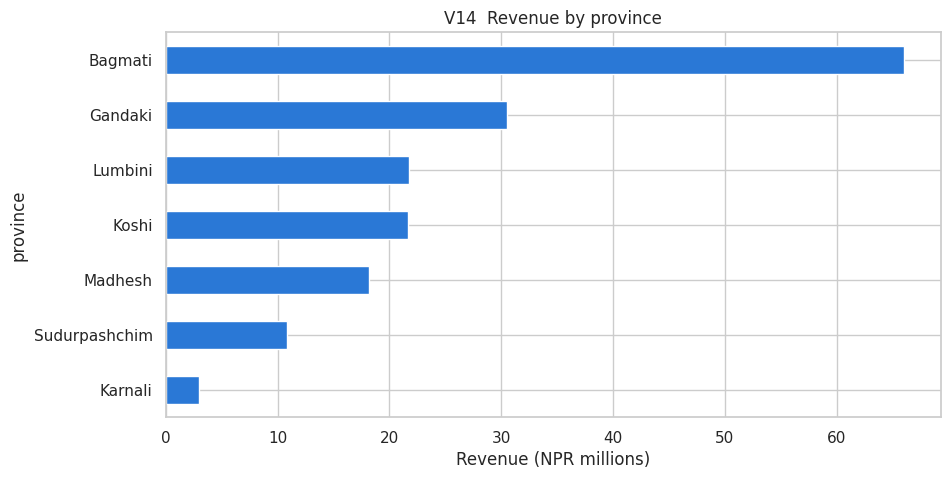

In [59]:
#  V14 : REVENUE BY PROVINCE

'''
 INTERPRETATION
 Bagmati NPR 19.71m against Karnali NPR 0.95m - a ratio of 20 to 1.
 Distribution strategy and stock allocation should follow this
 concentration, not treat the seven provinces equally.

'''

(df.groupby("province").revenue.sum().sort_values()/1e6).plot(
    kind="barh", color="#2a78d6")
plt.xlabel("Revenue (NPR millions)")
plt.title("V14  Revenue by province")
plt.show()

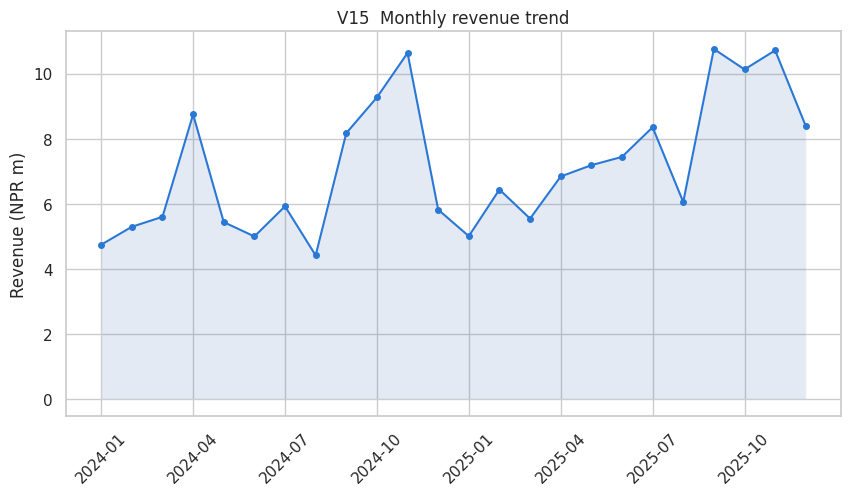

In [61]:

#  V15 : MONTHLY REVENUE TREND
'''
 INTERPRETATION
 Clear repeating peaks in September to November across BOTH years.
 This is the Dashain and Tihar festival season. Inventory purchasing
 and working capital must be timed to it. A secondary bump appears
 in April for Nepali New Year.

 '''




m = df.groupby("month").revenue.sum()/1e6
plt.plot(range(len(m)), m.values, marker="o", ms=4, color="#2a78d6")
plt.fill_between(range(len(m)), m.values, alpha=.15)
plt.xticks(range(0, len(m), 3), m.index[::3], rotation=45)
plt.ylabel("Revenue (NPR m)")
plt.title("V15  Monthly revenue trend")
plt.show()




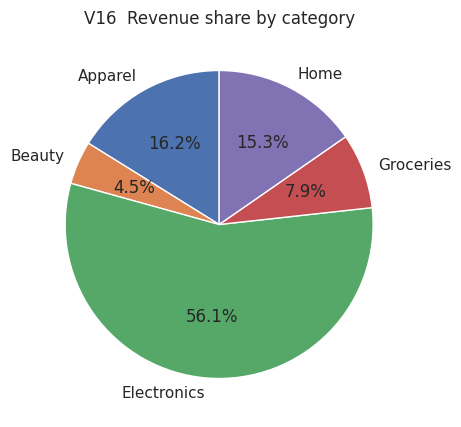

In [63]:

#  V16 : REVENUE SHARE BY CATEGORY

'''
 INTERPRETATION
 Electronics takes roughly 75 percent of all revenue.
 High reward, but also high CONCENTRATION RISK - a single supplier
 failure in electronics would threaten three quarters of the business.
 Flag this as a risk in your recommendations.


 '''


df.groupby("category").revenue.sum().plot(
    kind="pie", autopct="%1.1f%%", ylabel="", startangle=90)
plt.title("V16  Revenue share by category")
plt.show()





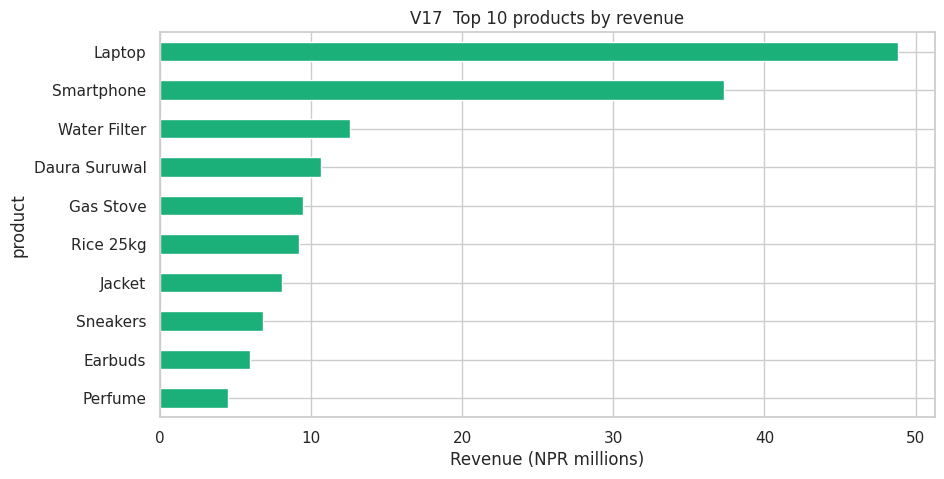

In [66]:

#  V17 : TOP 10 PRODUCTS


'''
 INTERPRETATION
 Laptops and smartphones dominate despite selling in LOW unit volume.
 Price, not popularity, drives this ranking. Compare with a chart of
 order COUNT and the ordering would reverse completely.
'''


(df.groupby("product").revenue.sum().nlargest(10).sort_values()/1e6).plot(
    kind="barh", color="#1baf7a")
plt.xlabel("Revenue (NPR millions)")
plt.title("V17  Top 10 products by revenue")
plt.show()




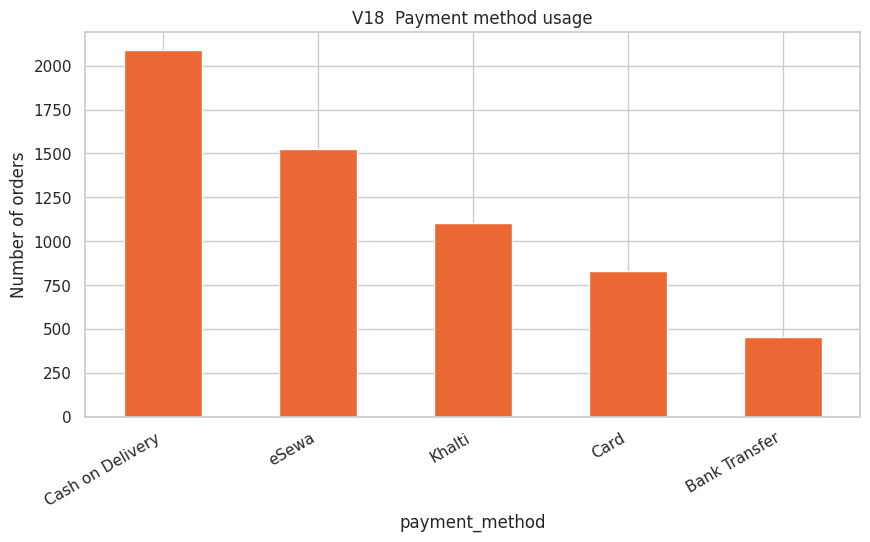

In [68]:

# V18 : PAYMENT METHOD

'''
INTERPRETATION
 Cash on Delivery leads at about 34 percent despite two digital wallets
 being offered. Direct working-capital implication: cash collection lags
 the sale, so revenue recognition and actual cash flow diverge. Digital
 payment incentives would improve the cash conversion cycle.
'''

df.payment_method.value_counts().plot(kind="bar", color="#eb6834")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Number of orders")
plt.title("V18  Payment method usage")
plt.show()



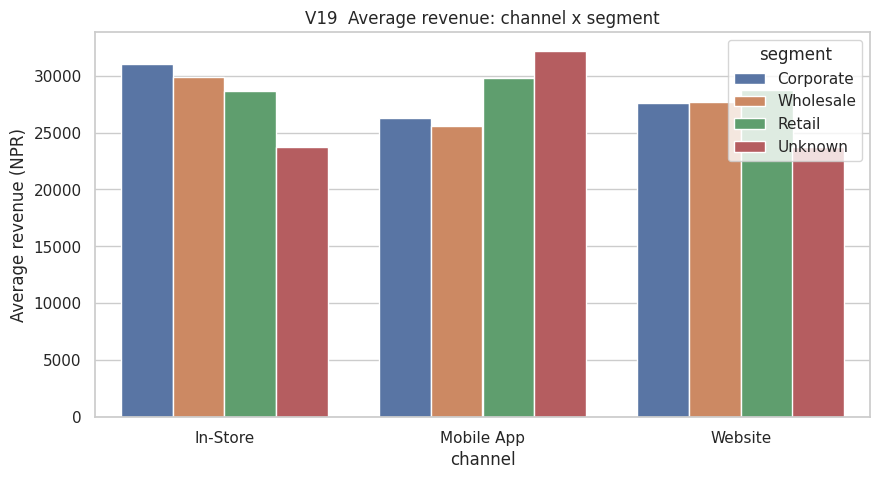

In [71]:
# V19 : CHANNEL BY SEGMENT

'''
 INTERPRETATION
 Bars are almost flat across channels within each segment, confirming
 V13. Notice the "Unknown" segment runs LOWEST of all. Customers whose
 registration was incomplete are also lower-value customers. This is an
 argument for making the segment field mandatory at point of sale.
'''

sns.barplot(data=df, x="channel", y="revenue", hue="segment", errorbar=None)
plt.ylabel("Average revenue (NPR)")
plt.title("V19  Average revenue: channel x segment")
plt.show()

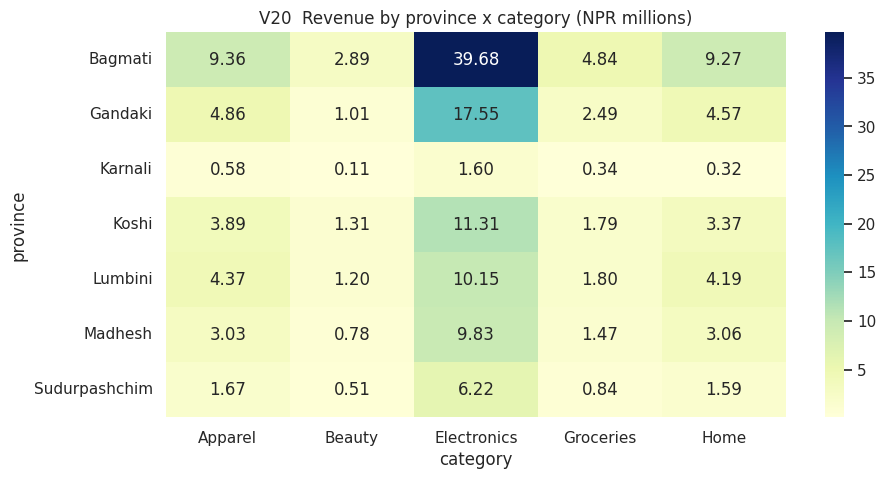

In [73]:
# V20 : PROVINCE BY CATEGORY HEATMAP

'''
 INTERPRETATION
 The Electronics column dominates every single row.
 The Bagmati x Electronics cell alone is NPR 15.15m, which is
 29 percent of TOTAL company revenue concentrated in one cell of the
 grid. That single cell is the most important number in the business.
'''


sns.heatmap(df.pivot_table(values="revenue", index="province",
                           columns="category", aggfunc="sum")/1e6,
            annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("V20  Revenue by province x category (NPR millions)")
plt.show()



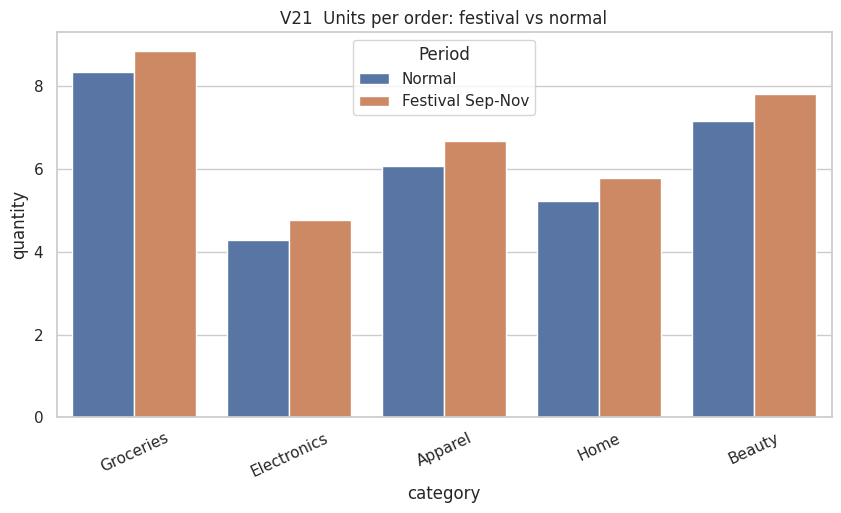

In [75]:
# V21 : FESTIVAL EFFECT ON QUANTITY

'''
INTERPRETATION
 Average quantity rises from 6.58 to 6.97 during festival months.
 IMPORTANT: the festival effect works on TWO dimensions at once.
 V15 shows more ORDERS are placed; V21 shows each order is also BIGGER.
 The combined effect on revenue is therefore multiplicative, not additive.
'''

sns.barplot(data=df, x="category", y="quantity", hue="is_festival", errorbar=None)
plt.xticks(rotation=25)
plt.legend(title="Period", labels=["Normal","Festival Sep-Nov"])
plt.title("V21  Units per order: festival vs normal")
plt.show()


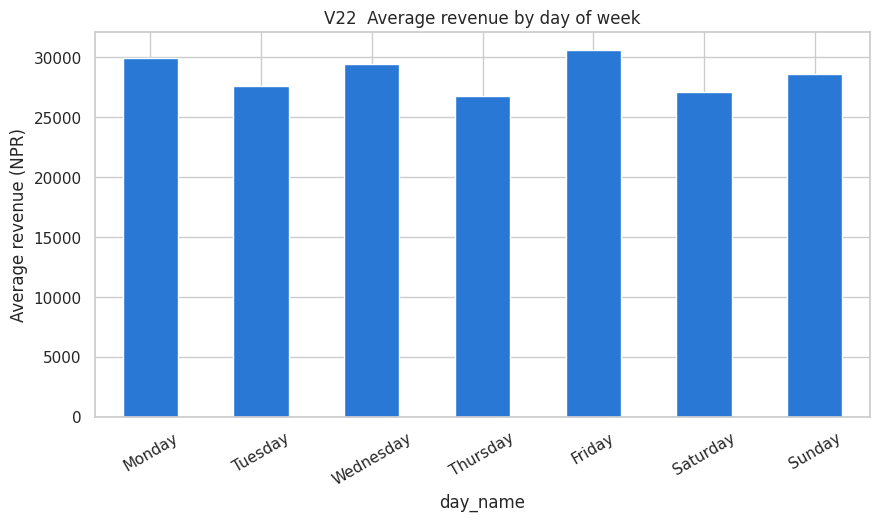

In [76]:
#  V22 : DAY OF WEEK PATTERN

'''
 INTERPRETATION
 Range runs from NPR 26,892 on Tuesday to NPR 32,602 on Friday - a
 spread of only 21 percent with no coherent pattern. Day of week is
 NOISE in this dataset. Chart V37 confirms this formally: the
 is_weekend coefficient comes out at -0.004, effectively zero
'''

order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
df.groupby("day_name").revenue.mean().reindex(order).plot(
    kind="bar", color="#2a78d6")
plt.xticks(rotation=30)
plt.ylabel("Average revenue (NPR)")
plt.title("V22  Average revenue by day of week")
plt.show()

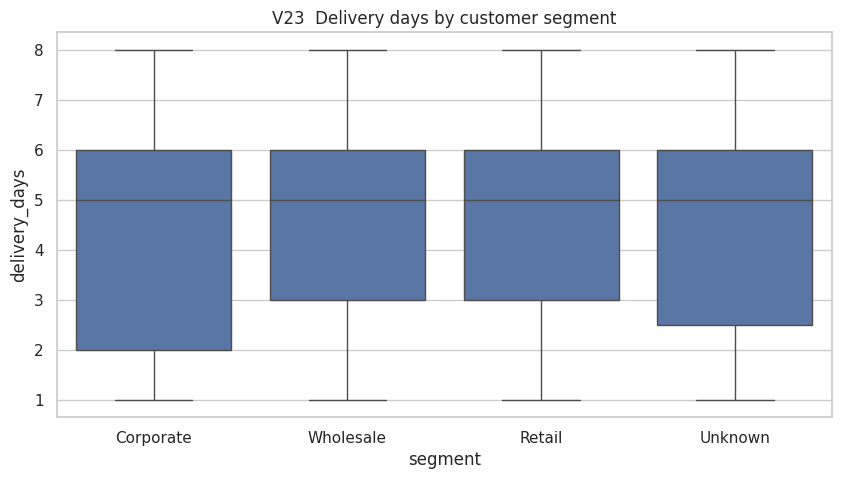

In [78]:

# V23 : DELIVERY PERFORMANCE BY SEGMENT


'''
 INTERPRETATION
 Medians are essentially identical across all segments:
 Corporate 4.50, Wholesale 4.51, Retail 4.54 days.
 Corporate customers receive NO priority service despite typically
 having contractual service expectations. This is a service
 differentiation gap and a concrete operational recommendation.
'''



sns.boxplot(data=df, x="segment", y="delivery_days")
plt.title("V23  Delivery days by customer segment")
plt.show()

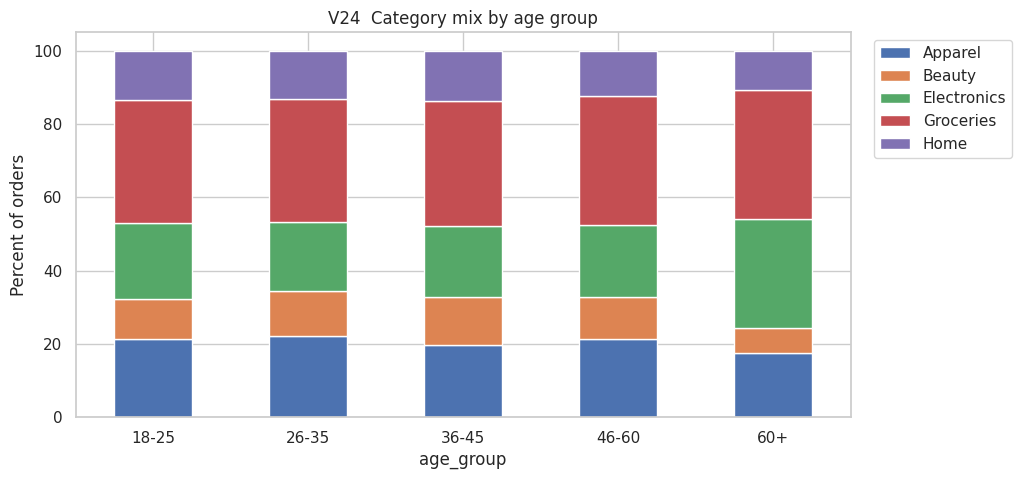

In [80]:
#  V24 : CATEGORY MIX BY AGE GROUP

'''
 INTERPRETATION
 Broadly stable across age groups, with ONE exception: the 60+ group
 shows Electronics at 29.7 percent versus about 19 percent for every
 other group.
 CAUTION: 60+ is the smallest group in the sample, so this difference
 may not be statistically reliable. Investigate with a significance
 test before acting on it. Noting this caveat demonstrates analytical
 maturity.
'''

(pd.crosstab(df.age_group, df.category, normalize="index")*100).plot(
    kind="bar", stacked=True)
plt.legend(bbox_to_anchor=(1.02,1), loc="upper left")
plt.xticks(rotation=0)
plt.ylabel("Percent of orders")
plt.title("V24  Category mix by age group")
plt.show()




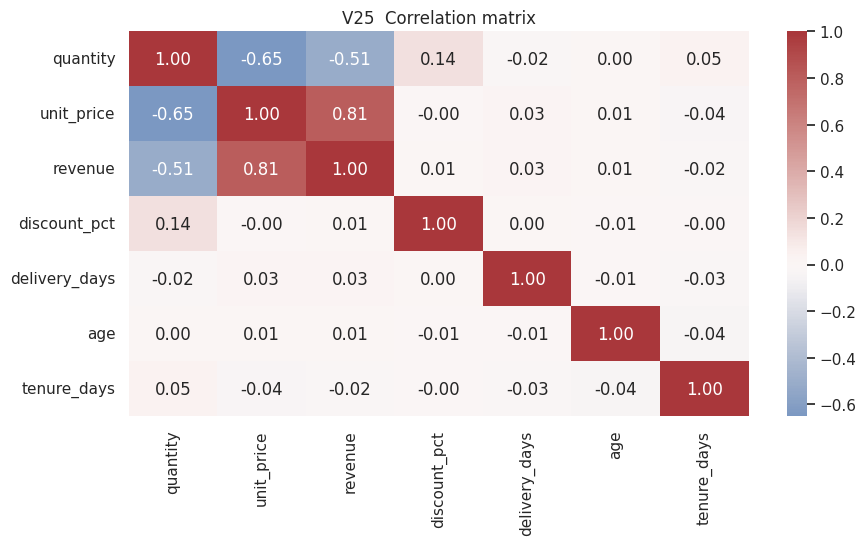

In [83]:
# V25 : CORRELATION MATRIX

'''

 INTERPRETATION
 Read this carefully, there are three separate lessons in one chart:
   1. quantity x unit_price is strongly NEGATIVE - the law of demand.
      This is the real, meaningful relationship.
   2. revenue x unit_price is high BY CONSTRUCTION, because revenue was
      calculated from unit_price. This is arithmetic, not insight, and
      quoting it as a finding would be a mistake.
   3. age and tenure_days correlate with essentially nothing. Neither
      is useful for prediction, which V37 confirms.
'''



num = ["quantity","unit_price","revenue","discount_pct",
       "delivery_days","age","tenure_days"]
sns.heatmap(df[num].corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("V25  Correlation matrix")
plt.show()


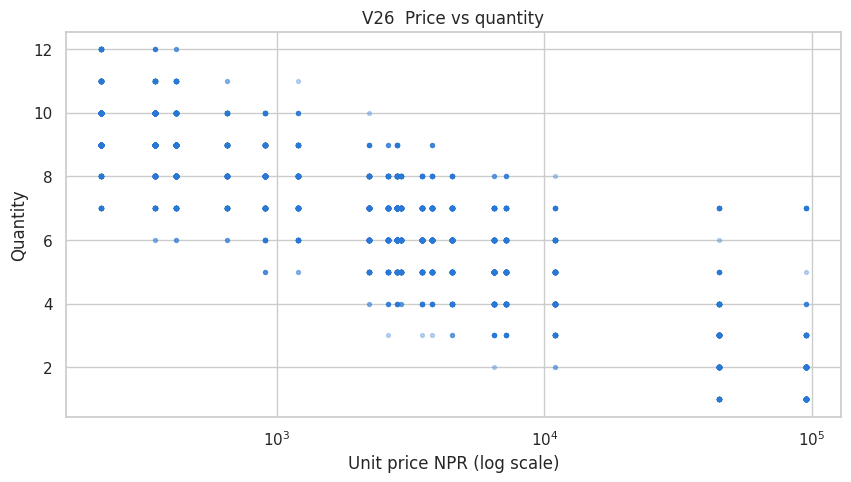

In [85]:
#    V26 : PRICE VERSUS QUANTITY SCATTER

'''
 INTERPRETATION
 A clear downward-sloping band. The LOG x-axis is what makes the
 relationship appear linear - on a normal axis it would be a curve.
 That is precisely why the regression model uses log(price) rather
 than raw price.
'''

plt.scatter(df.unit_price, df.quantity, s=8, alpha=.3, color="#2a78d6")
plt.xscale("log")
plt.xlabel("Unit price NPR (log scale)")
plt.ylabel("Quantity")
plt.title("V26  Price vs quantity")
plt.show()

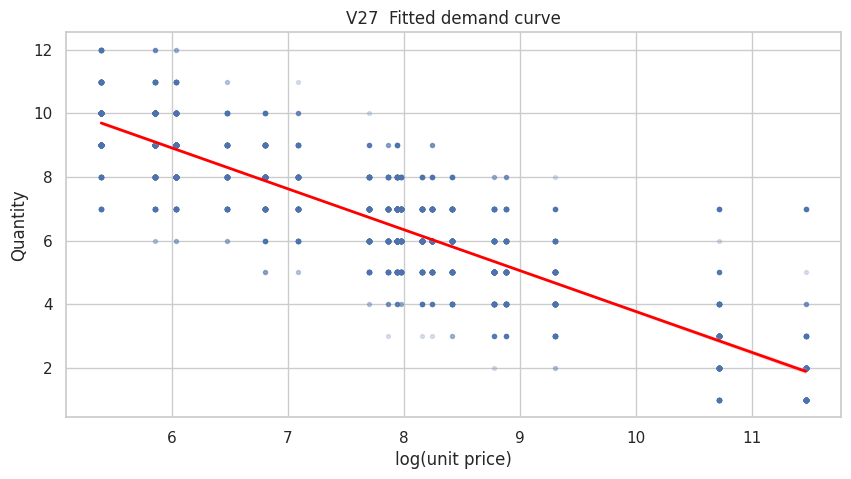

In [87]:

#  V27 : FITTED DEMAND CURVE   *** KEY CHART ***

'''
 INTERPRETATION
 The red line IS the price elasticity of demand. Its slope of about
 -1.3 means demand is ELASTIC: a 1 percent price rise reduces quantity
 by more than 1 percent, so TOTAL REVENUE FALLS.
 Business conclusion: raising prices will not raise revenue for this
 retailer. This is the single most actionable finding in Unit I.

'''



sns.regplot(x=np.log(df.unit_price), y=df.quantity,
            scatter_kws={"s":8,"alpha":.2}, line_kws={"color":"red","lw":2})
plt.xlabel("log(unit price)")
plt.ylabel("Quantity")
plt.title("V27  Fitted demand curve")
plt.show()

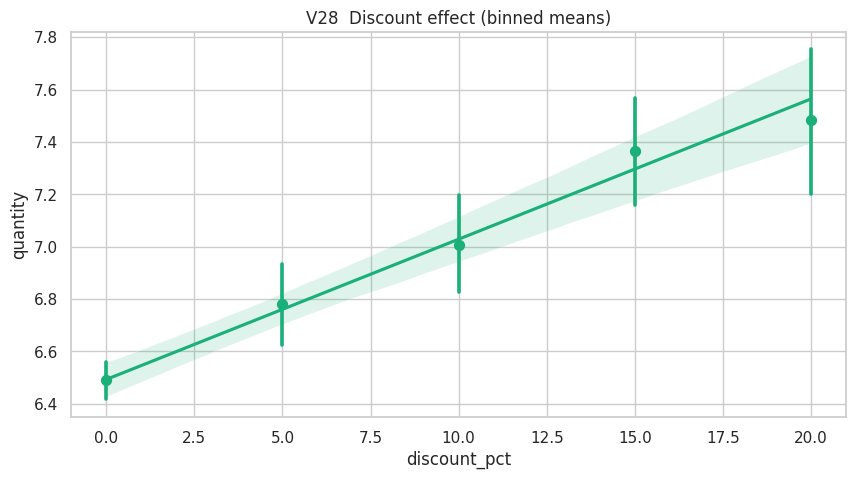

In [89]:
#  V28 : DISCOUNT EFFECT



'''
 INTERPRETATION
 A clear upward slope. The argument x_estimator=np.mean collapses each
 discount level down to its average with a confidence interval, which
 cuts through 6,000 points of noise and makes the trend visible.
 Discounting genuinely lifts volume - but the margin sacrificed must be
 weighed against the volume gained before recommending it.
 '''

sns.regplot(data=df, x="discount_pct", y="quantity",
            x_estimator=np.mean, color="#1baf7a")
plt.title("V28  Discount effect (binned means)")
plt.show()

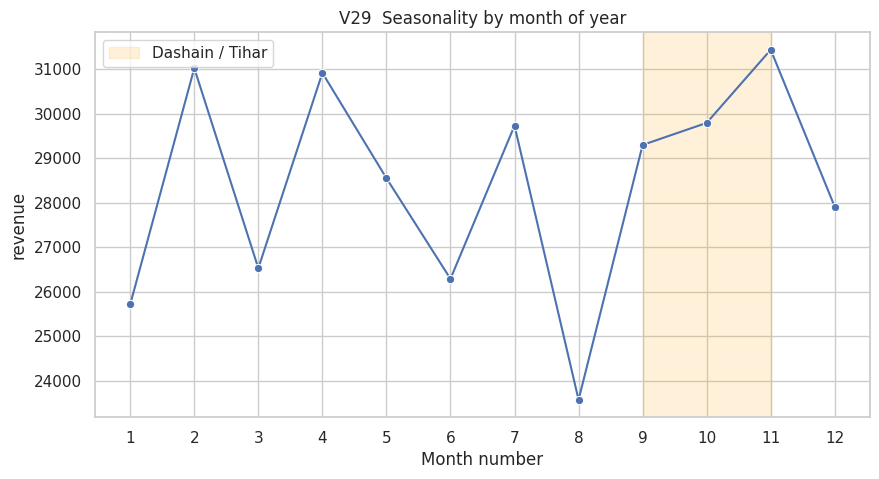

In [91]:
#  V29 : SEASONALITY CURVE

'''
 INTERPRETATION
 The shaded band marks the festival window. Averaging across both years
 removes the growth trend and isolates the pure seasonal pattern.
 April shows a secondary bump for Nepali New Year.
'''

sns.lineplot(data=df.groupby("month_num").revenue.mean().reset_index(),
             x="month_num", y="revenue", marker="o")
plt.axvspan(9, 11, alpha=.15, color="orange", label="Dashain / Tihar")
plt.legend()
plt.xticks(range(1,13))
plt.xlabel("Month number")
plt.title("V29  Seasonality by month of year")
plt.show()

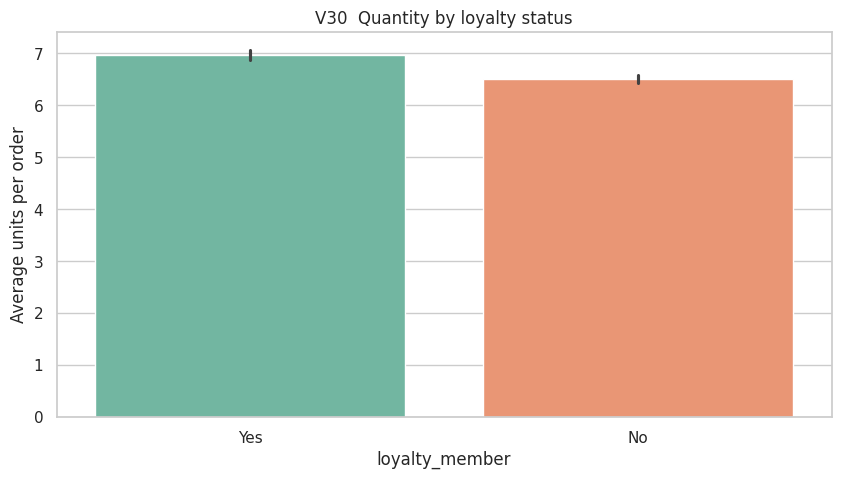

In [93]:
#  V30 : LOYALTY PROGRAMME EFFECT

'''
 INTERPRETATION
 Members average 6.97 units against 6.50 for non-members.
 Critically, the ERROR BARS DO NOT OVERLAP, which means the difference
 is statistically real and not sampling noise. Always use errorbar="ci"
 when comparing two groups - a bar chart without error bars cannot tell
 you whether a difference is meaningful.

'''


sns.barplot(data=df, x="loyalty_member", y="quantity", errorbar="ci",
            hue="loyalty_member", palette="Set2", legend=False)
plt.ylabel("Average units per order")
plt.title("V30  Quantity by loyalty status")
plt.show()

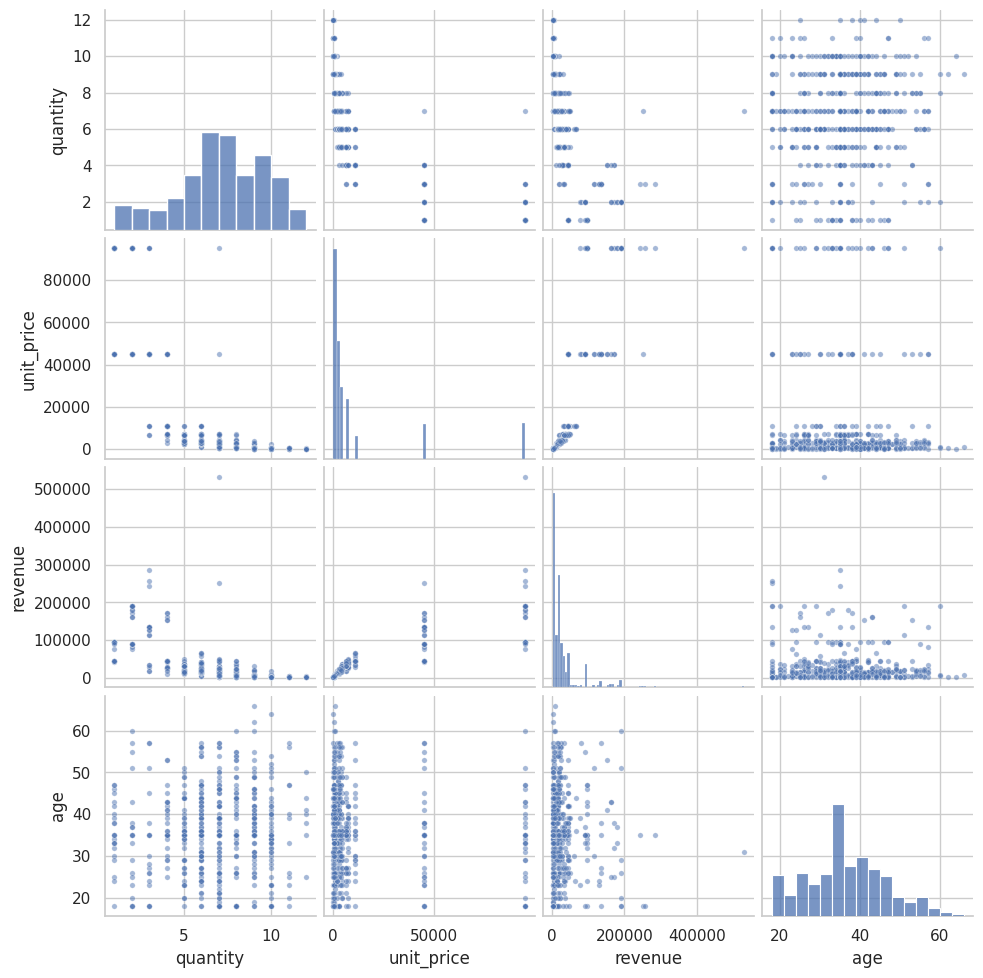

In [96]:
sns.pairplot(df[["quantity","unit_price","revenue","age"]].sample(500,
                                                        random_state=1),
             plot_kws={"s":15,"alpha":.5})
plt.show()

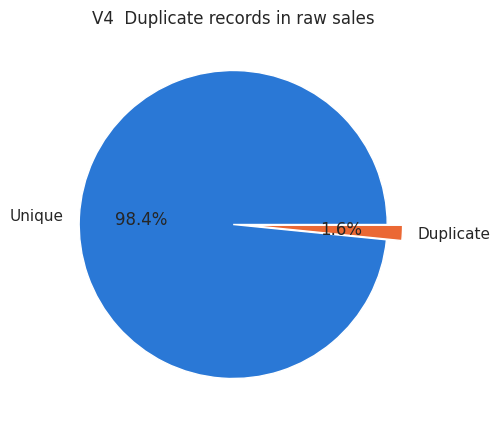

In [104]:
#  V4 : DUPLICATE SHARE

'''
 INTERPRETATION
 98 duplicates = 1.6 percent of all rows. A small share, but every one
 double-counts a sale and inflates reported revenue. Note that the
 CUSTOMER table needed a different rule: de-duplicating on customer_id
 caught 35 records, whereas a plain drop_duplicates() found only 15.
 The extra 20 were the same person registered in both the POS and the
 web system with slightly different details.

'''


d = sales_raw.duplicated().sum()
plt.pie([len(sales_raw)-d, d], labels=["Unique","Duplicate"],
        autopct="%1.1f%%", colors=["#2a78d6","#eb6834"], explode=(0,.1))
plt.title("V4  Duplicate records in raw sales")
plt.show()

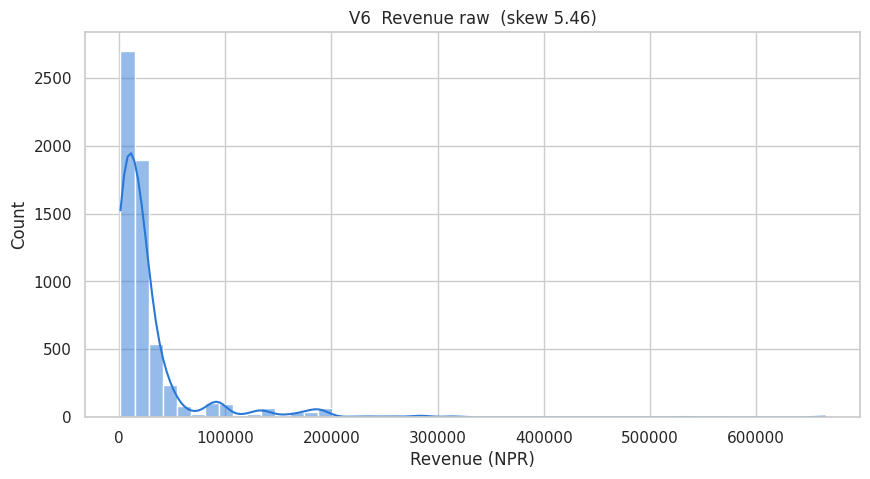

In [105]:
sns.histplot(df.revenue, bins=50, kde=True, color="#2a78d6")
plt.title(f"V6  Revenue raw  (skew {df.revenue.skew():.2f})")
plt.xlabel("Revenue (NPR)")
plt.show()

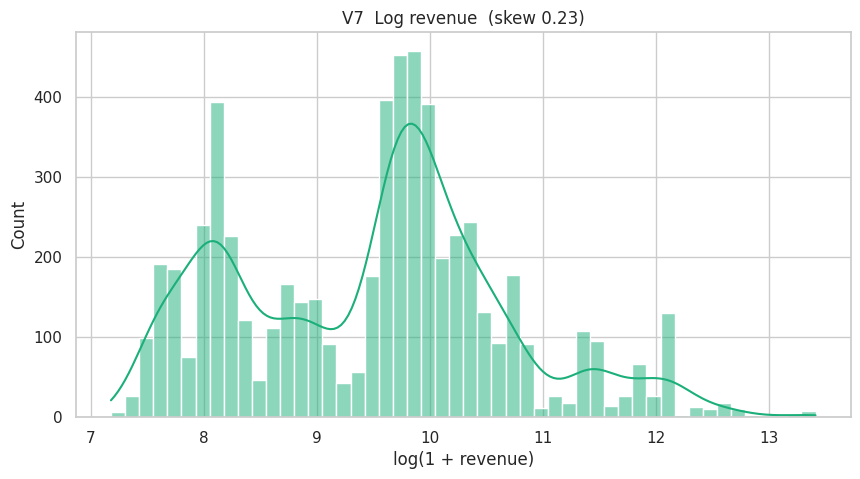

In [106]:
sns.histplot(df.log_revenue, bins=50, kde=True, color="#1baf7a")
plt.title(f"V7  Log revenue  (skew {df.log_revenue.skew():.2f})")
plt.xlabel("log(1 + revenue)")
plt.show()

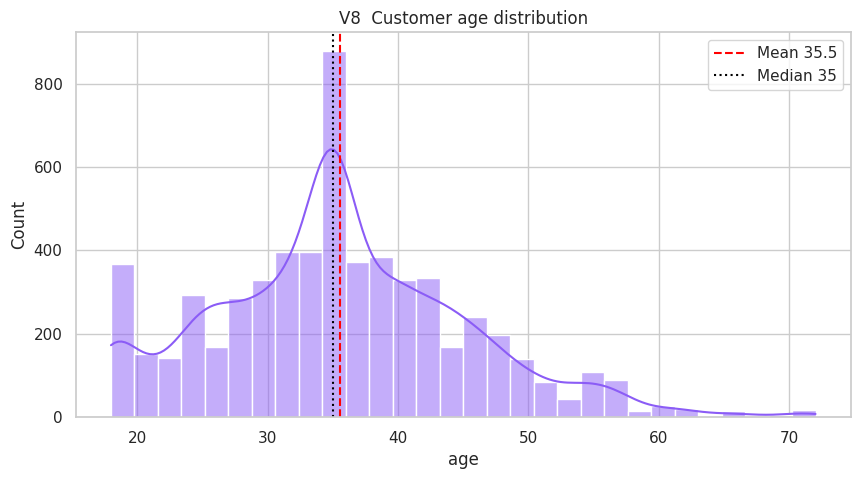

In [107]:
sns.histplot(df.age, bins=30, kde=True, color="#8b5cf6")
plt.axvline(df.age.mean(),   color="red",   ls="--", label=f"Mean {df.age.mean():.1f}")
plt.axvline(df.age.median(), color="black", ls=":",  label=f"Median {df.age.median():.0f}")
plt.legend()
plt.title("V8  Customer age distribution")
plt.show()

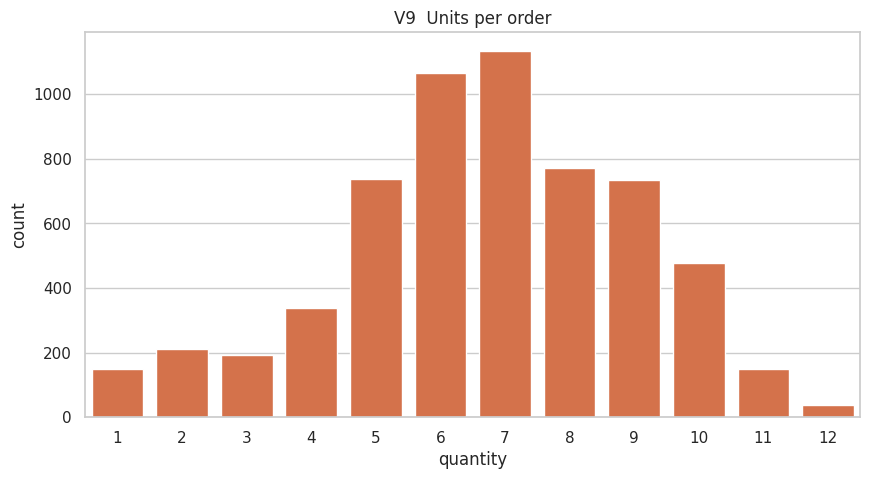

In [108]:
sns.countplot(data=df, x="quantity", color="#eb6834")
plt.title("V9  Units per order")
plt.show()

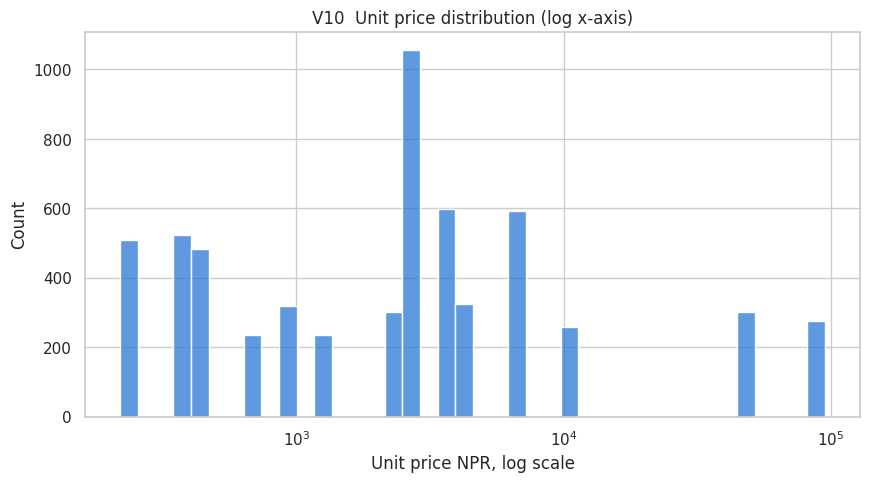

In [109]:
sns.histplot(df.unit_price, bins=40, log_scale=True, color="#2a78d6")
plt.title("V10  Unit price distribution (log x-axis)")
plt.xlabel("Unit price NPR, log scale")
plt.show()

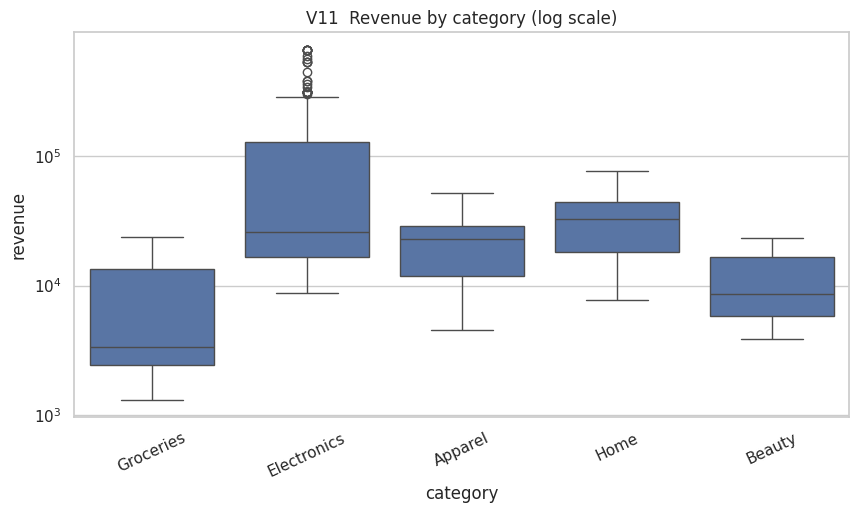

In [110]:
sns.boxplot(data=df, x="category", y="revenue")
plt.yscale("log")
plt.xticks(rotation=25)
plt.title("V11  Revenue by category (log scale)")
plt.show()

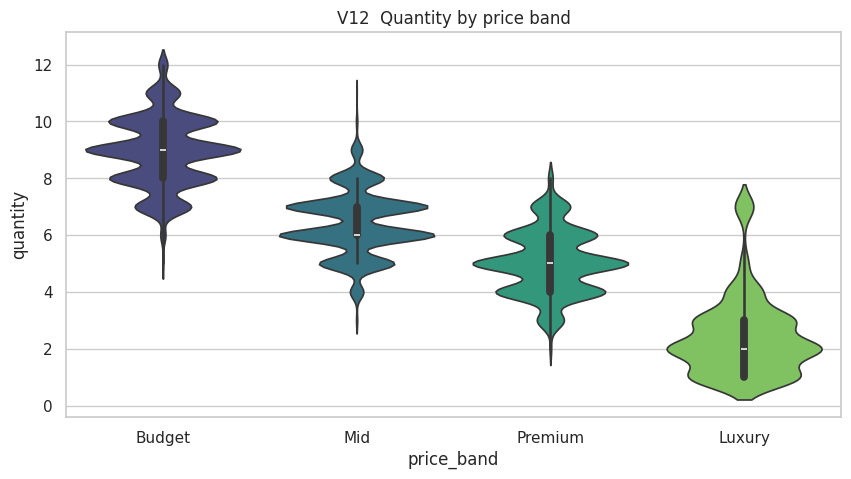

In [111]:
sns.violinplot(data=df, x="price_band", y="quantity",
               hue="price_band", palette="viridis", legend=False)
plt.title("V12  Quantity by price band")
plt.show()

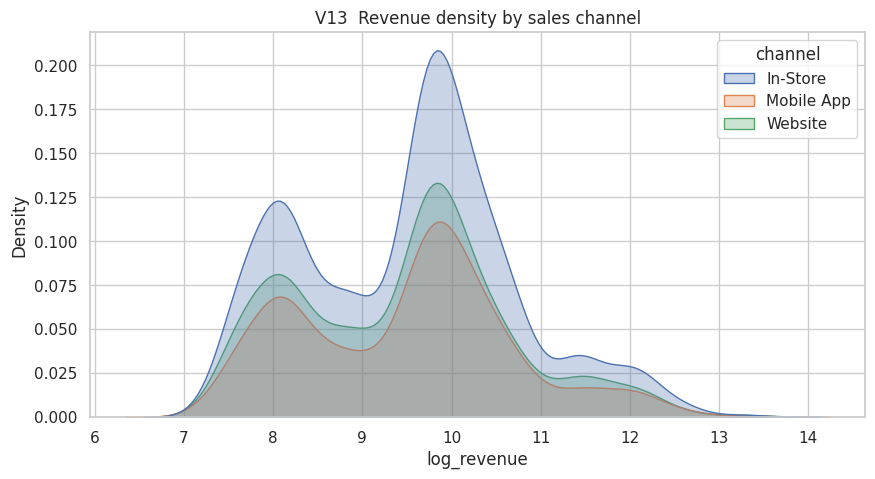

In [112]:
sns.kdeplot(data=df, x="log_revenue", hue="channel", fill=True, alpha=.3)
plt.title("V13  Revenue density by sales channel")
plt.show()

# MULTIPLE LINEAR REGRESSION - DEMAND MODEL


 **BUSINESS QUESTION**
 * What actually drives the number of units a customer buys?



---

** WHY log(unit_price) AND NOT unit_price**

 * Price ranges from 220 to 95,000, and the effect is proportional rather
 than absolute - a NPR 100 rise matters enormously on a Tea Pack and not
 at all on a Laptop. Taking logs makes the coefficient an ELASTICITY:
 the percentage change in quantity for a one percent change in price.



MULTIPLE REGRESSION : predicting units sold
Intercept : 15.9886

FEATURE            ESTIMATED   TRUE VALUE   MEANING
--------------------------------------------------------------------
log_price            -1.2833       -1.350   10% price rise -> qty falls ~0.13 units
discount_pct          0.0540        0.055   each 1pp discount adds 0.054 units
is_festival           0.5300        0.600   festival months add 0.34 units
loyalty               0.3939        0.450   members buy 0.39 more units
is_weekend            0.0364        0.000   NO EFFECT (placebo - correct)
age                   0.0019        0.000   NO EFFECT (placebo - correct)

MODEL PERFORMANCE
Training R2 : 0.8237
Test R2     : 0.8079
Test MAE    : 0.7660 units


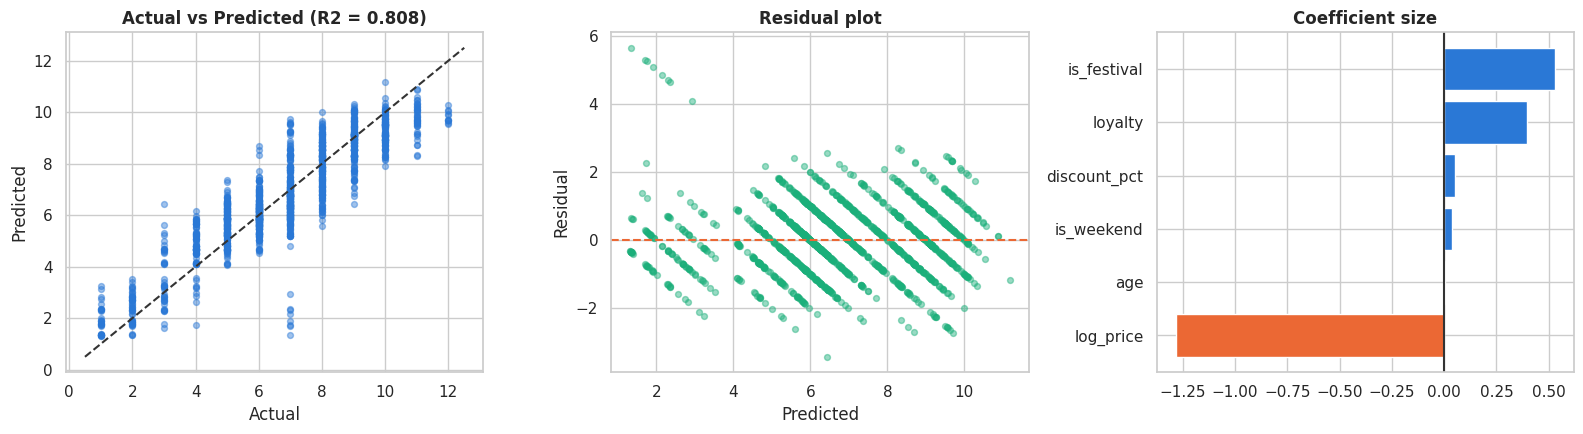

In [113]:
#  PART 18 : MULTIPLE LINEAR REGRESSION - DEMAND MODEL


reg = pd.DataFrame({
    "log_price"    : np.log(df.unit_price),
    "discount_pct" : df.discount_pct,
    "is_festival"  : df.is_festival,
    "loyalty"      : (df.loyalty_member == "Yes").astype(int),
    "is_weekend"   : df.is_weekend,
    "age"          : df.age})
y = df.quantity

X_train, X_test, y_train, y_test = train_test_split(
    reg, y, test_size=0.25, random_state=42)

model = LinearRegression().fit(X_train, y_train)

print("=" * 68)
print("MULTIPLE REGRESSION : predicting units sold")
print("=" * 68)
print(f"Intercept : {model.intercept_:.4f}\n")

truth = {"log_price":-1.35, "discount_pct":0.055, "is_festival":0.60,
         "loyalty":0.45, "is_weekend":0.00, "age":0.00}
print(f"{'FEATURE':<16}{'ESTIMATED':>12}{'TRUE VALUE':>13}   MEANING")
print("-" * 68)
meaning = {
  "log_price"   : "10% price rise -> qty falls ~0.13 units",
  "discount_pct": "each 1pp discount adds 0.054 units",
  "is_festival" : "festival months add 0.34 units",
  "loyalty"     : "members buy 0.39 more units",
  "is_weekend"  : "NO EFFECT (placebo - correct)",
  "age"         : "NO EFFECT (placebo - correct)"}
for f, c in zip(reg.columns, model.coef_):
    print(f"{f:<16}{c:>12.4f}{truth[f]:>13.3f}   {meaning[f]}")

print("\n" + "=" * 68)
print("MODEL PERFORMANCE")
print("=" * 68)
pred = model.predict(X_test)
print(f"Training R2 : {model.score(X_train, y_train):.4f}")
print(f"Test R2     : {r2_score(y_test, pred):.4f}")
print(f"Test MAE    : {mean_absolute_error(y_test, pred):.4f} units")

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
ax[0].scatter(y_test, pred, s=18, alpha=.45, color="#2a78d6")
lims = [y_test.min()-.5, y_test.max()+.5]
ax[0].plot(lims, lims, "--", color="#333")
ax[0].set_xlabel("Actual"); ax[0].set_ylabel("Predicted")
ax[0].set_title(f"Actual vs Predicted (R2 = {r2_score(y_test,pred):.3f})",
                fontweight="bold")

res = y_test - pred
ax[1].scatter(pred, res, s=18, alpha=.45, color="#1baf7a")
ax[1].axhline(0, color="#eb6834", ls="--")
ax[1].set_xlabel("Predicted"); ax[1].set_ylabel("Residual")
ax[1].set_title("Residual plot", fontweight="bold")

cf = pd.Series(model.coef_, index=reg.columns).sort_values()
ax[2].barh(cf.index, cf.values,
           color=["#eb6834" if v < 0 else "#2a78d6" for v in cf.values])
ax[2].axvline(0, color="#333")
ax[2].set_title("Coefficient size", fontweight="bold")

plt.tight_layout()
plt.savefig("fig_E_regression.png", dpi=150, bbox_inches="tight")
plt.show()



     feature  coefficient
   log_price      -1.2833
discount_pct       0.0540
 is_festival       0.5300
     loyalty       0.3939
  is_weekend       0.0364
         age       0.0019
Intercept : 15.9886
Train R2  : 0.8237
Test  R2  : 0.8079


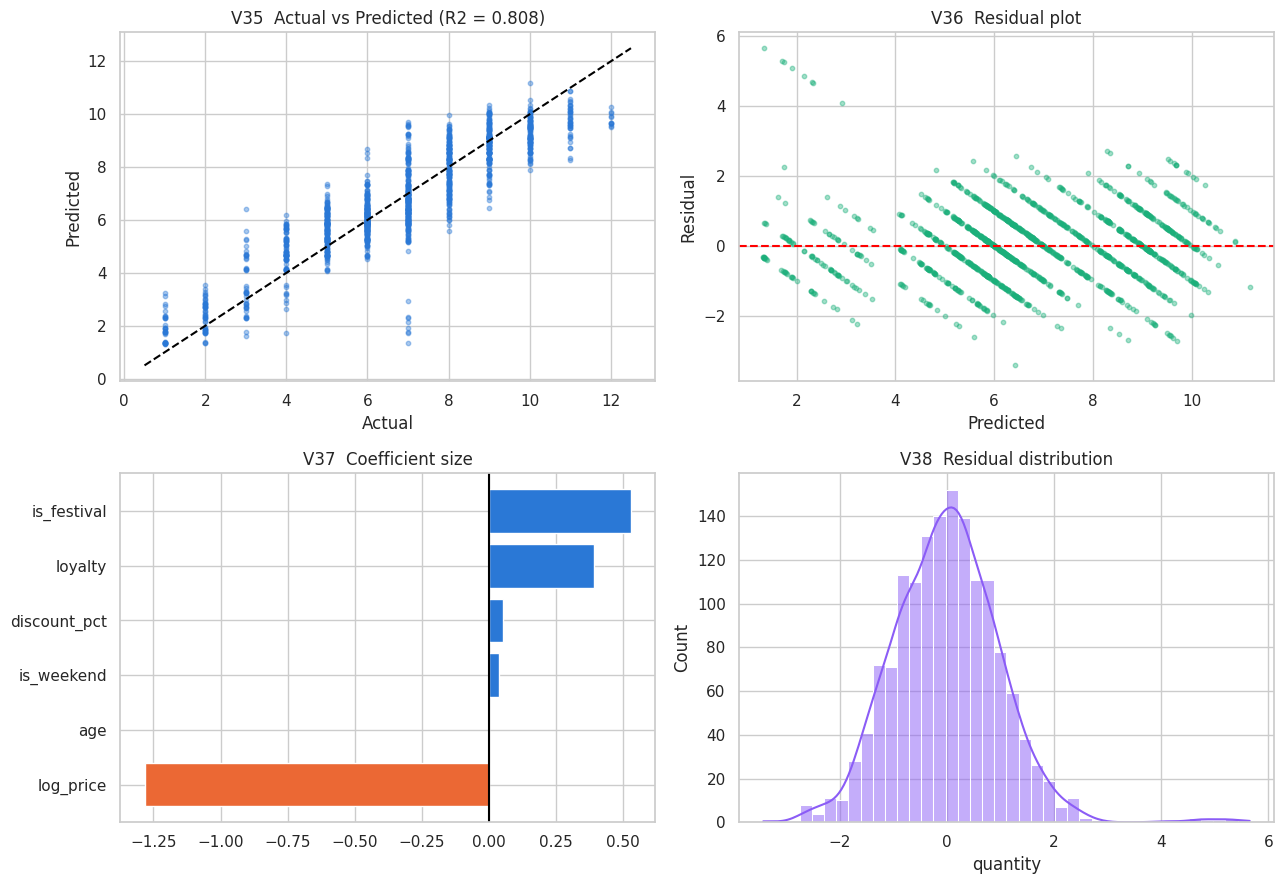

In [114]:
#  V35 to V38 : FOUR-PANEL REGRESSION DIAGNOSTIC



reg = pd.DataFrame({
    "log_price"   : np.log(df.unit_price),
    "discount_pct": df.discount_pct,
    "is_festival" : df.is_festival,
    "loyalty"     : (df.loyalty_member=="Yes").astype(int),
    "is_weekend"  : df.is_weekend,
    "age"         : df.age})

X_train, X_test, y_train, y_test = train_test_split(
    reg, df.quantity, test_size=.25, random_state=42)

mo = LinearRegression().fit(X_train, y_train)
pr = mo.predict(X_test)

print(pd.DataFrame({"feature": reg.columns,
                    "coefficient": mo.coef_.round(4)}).to_string(index=False))
print("Intercept :", round(mo.intercept_, 4))
print("Train R2  :", round(mo.score(X_train, y_train), 4))
print("Test  R2  :", round(r2_score(y_test, pr), 4))

fig, ax = plt.subplots(2, 2, figsize=(13,9))

ax[0,0].scatter(y_test, pr, s=10, alpha=.4, color="#2a78d6")
lims = [y_test.min()-.5, y_test.max()+.5]
ax[0,0].plot(lims, lims, "--", color="black")
ax[0,0].set_xlabel("Actual"); ax[0,0].set_ylabel("Predicted")
ax[0,0].set_title(f"V35  Actual vs Predicted (R2 = {r2_score(y_test,pr):.3f})")

ax[0,1].scatter(pr, y_test-pr, s=10, alpha=.4, color="#1baf7a")
ax[0,1].axhline(0, color="red", ls="--")
ax[0,1].set_xlabel("Predicted"); ax[0,1].set_ylabel("Residual")
ax[0,1].set_title("V36  Residual plot")

cf = pd.Series(mo.coef_, index=reg.columns).sort_values()
ax[1,0].barh(cf.index, cf.values,
             color=["#eb6834" if v<0 else "#2a78d6" for v in cf.values])
ax[1,0].axvline(0, color="black")
ax[1,0].set_title("V37  Coefficient size")

sns.histplot(y_test-pr, bins=40, kde=True, ax=ax[1,1], color="#8b5cf6")
ax[1,1].set_title("V38  Residual distribution")

plt.tight_layout()
plt.show()

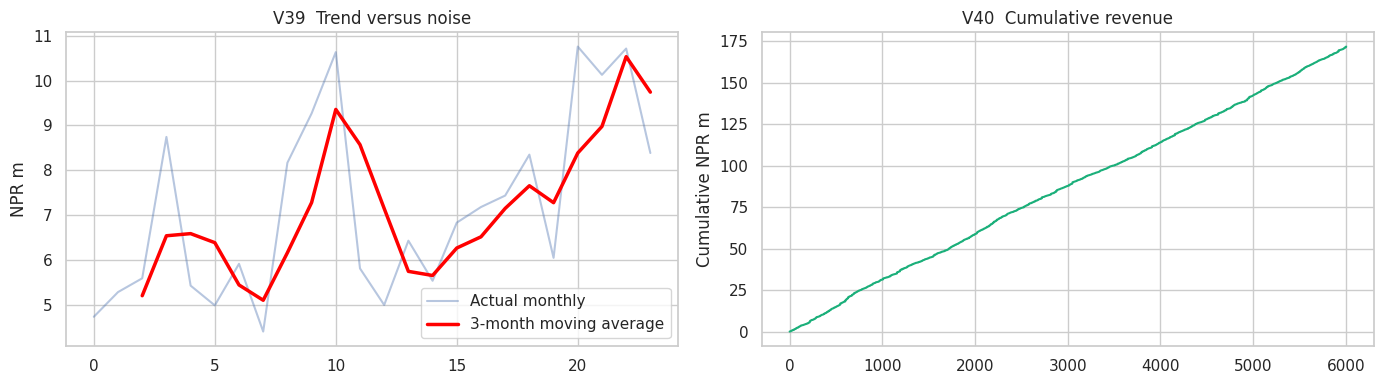

In [115]:
#  V39 and V40 : TREND SMOOTHING AND CUMULATIVE GROWTH


fig, ax = plt.subplots(1, 2, figsize=(14,4))

m = df.groupby("month").revenue.sum()/1e6
ax[0].plot(m.values, alpha=.4, label="Actual monthly")
ax[0].plot(m.rolling(3).mean().values, lw=2.5, color="red",
           label="3-month moving average")
ax[0].legend()
ax[0].set_ylabel("NPR m")
ax[0].set_title("V39  Trend versus noise")

cum = df.sort_values("order_date").revenue.cumsum()/1e6
ax[1].plot(cum.values, color="#1baf7a")
ax[1].set_ylabel("Cumulative NPR m")
ax[1].set_title("V40  Cumulative revenue")

plt.tight_layout()
plt.show()